# 区分マンション投資シミュレーター（ベース版）

## 目的
不動産投資（区分マンション）の基本的なキャッシュフロー・損益計算・時価評価を
月次ベースでシミュレーションし、投資判断の材料を提供する。

## 対応範囲（本バージョン）
- 1物件・単一シナリオ
- 月次キャッシュフロー / 年次キャッシュフロー
- 月次PL / 年次PL
- ローン残高推移（元利均等・固定金利）
- 建物減価償却（定額法・中古耐用年数）
- 土地・建物 想定時価推移
- 含み損益・純資産相当額推移

## 将来拡張予定
- 売却シミュレーション / 売却コスト / 譲渡税
- 所得税・住民税の簡易計算（税引後CF）
- 金利上昇・空室率変動シナリオ
- 複数シナリオ比較 / 感度分析
- 複数物件ポートフォリオ対応

## 使い方
**設定セル（セル3）のパラメータを変更するだけで、別物件にも転用できます。**
物件情報・ローン条件・賃料・シナリオ想定を上書きして再実行してください。

In [2]:
# === セル2: 依存ライブラリ import ===

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import japanize_matplotlib  # noqa: F401  — 日本語フォント（IPAexGothic）を自動設定
from dataclasses import dataclass, asdict
from typing import Optional
from pathlib import Path
from datetime import date, datetime
import logging
import math
import unicodedata

plt.rcParams["axes.unicode_minus"] = False

pd.options.display.float_format = "{:,.0f}".format
pd.set_option("display.max_columns", 50)

logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
logger = logging.getLogger(__name__)

print("ライブラリ読み込み完了")
print(f"display.max_columns: {pd.get_option('display.max_columns')}")

ライブラリ読み込み完了
display.max_columns: 50


In [3]:
# === セル3: 設定パラメータ ===
# このセルのパラメータを変更するだけで、別物件のシミュレーションに転用できます。

# --- 物件情報 ---
PROPERTY_NAME = "ガリシア亀戸"
PROPERTY_ADDRESS = ""  # 物件住所
EXCLUSIVE_AREA_SQM = 25.56  # 専有面積 m²
STRUCTURE = "RC"  # RC / SRC / 鉄骨 / 木造
BUILT_YEAR_MONTH = "2025-10"  # 築年月 (YYYY-MM)
SIMULATION_START_DATE = "2026-01"  # シミュレーション開始年月 (YYYY-MM)
OWNER_AGE_AT_START = None  # オーナー年齢（シミュレーション開始時）。None なら非表示

# --- 初期条件 ---
PURCHASE_PRICE_JPY = 38_800_000  # 購入価格（円）
DOWN_PAYMENT_JPY = 0             # 頭金（円）— フルローン
ACQUISITION_MISC_COST_JPY = 1_600_000  # 取得時諸費用（円）（仲介手数料・登記費用・取得税等 ≈ 4%）
INITIAL_LOAN_RATE_ANNUAL = 0.0159  # ローン金利（年利）
LOAN_TERM_YEARS = 35  # ローン期間（年）
LAND_RATIO = 0.50  # 土地按分比率
BUILDING_RATIO = 0.50  # 建物按分比率

# --- 収入条件 ---
MONTHLY_RENT_JPY = 122_900  # 想定満室月額家賃（円）— 表面利回り3.8%より逆算
MONTHLY_PARKING_INCOME_JPY = 0  # 駐車場収入（月額）
MONTHLY_OTHER_INCOME_JPY = 0  # その他収入（月額）（自販機・看板等）
PARKING_GROWTH_ANNUAL = 0.0  # 駐車場収入年間成長率
OTHER_INCOME_GROWTH_ANNUAL = 0.0  # その他収入年間成長率

# --- シナリオ ---
VACANCY_RATE = 0.05  # 空室率（一律控除）
LAND_PRICE_GROWTH_ANNUAL = 0.005  # 土地価格年間上昇率
BUILDING_PRICE_GROWTH_ANNUAL = -0.005  # 建物価格年間上昇率（マイナス=下落）
RENT_GROWTH_ANNUAL = 0.0  # 家賃年間上昇率

# --- 支出条件 ---
FIXED_ASSET_TAX_RATE_ANNUAL = 0.014  # 固定資産税率（簡易：購入価格ベース）
CITY_PLANNING_TAX_RATE_ANNUAL = 0.0  # 都市計画税率（簡易：購入価格ベース）
PM_FEE_RATE = 0.05  # PM（賃貸管理）手数料率（実効家賃に対して）
FIRE_INSURANCE_ANNUAL_JPY = 15_000  # 火災保険料（年額）
EARTHQUAKE_INSURANCE_ANNUAL_JPY = 0  # 地震保険料（年額）
BUILDING_MANAGEMENT_FEE_MONTHLY_JPY = 0  # 管理費（月額）
REPAIR_RESERVE_MONTHLY_JPY = 8_000  # 修繕積立金（月額）
ROUTINE_REPAIR_MONTHLY_JPY = 0  # 通常修繕費（月額）

# --- 大規模修繕・一時費用イベント ---
LARGE_REPAIR_EVENTS = [
    # {"year": 7, "amount_jpy": 1_200_000, "label": "大規模修繕"},
]
ONE_TIME_COST_EVENTS = [
    # {"year": 5, "amount_jpy": 100_000, "label": "設備交換"},
]

# --- 入替コスト ---
LEASING_FEE_PER_TURNOVER_MONTHS = 0.0  # 入居募集費（家賃○ヶ月分）
LEASING_FIXED_COST_JPY = 0  # 入居募集固定費（原状回復等）
TURNOVER_INTERVAL_YEARS = None  # 入替周期（年）。None なら入替なし
VACANCY_MONTHS_PER_TURNOVER = 0  # 入替時空室月数（追加空室）

# --- 税務 ---
INCOME_TAX_RATE = 0.45  # 所得税率（簡易：不動産所得に対する限界税率）— MAX水準（高所得層）
RESIDENT_TAX_RATE = 0.10  # 住民税率（一律）
ALLOW_NEGATIVE_TAX_BENEFIT = True  # 赤字時の損益通算による税還付を認めるか

# --- 売却 ---
SALE_YEAR = None  # 売却年（保有年数）。None なら売却しない
SALE_PRICE_METHOD = "market_value"  # market_value / direct_input / cap_rate
DIRECT_SALE_PRICE_JPY = None  # 売却価格（direct_input 時）
EXIT_CAP_RATE = None  # キャップレート（cap_rate 時）
SELLING_BROKER_FEE_RATE = 0.03  # 売却仲介手数料率
SELLING_OTHER_COST_JPY = 0  # 売却その他費用
LOAN_PREPAYMENT_FEE_RATE = 0.0  # 繰上返済手数料率（ローン残高に対して）
CAPITAL_GAINS_TAX_RATE = 0.20315  # 譲渡所得税率（長期）

# --- 実行条件 ---
HOLDING_PERIOD_YEARS = 35  # ローン期間に合わせて35年
ENABLE_SAVE = True
OUTPUT_DIR = Path().cwd()
ENABLE_DEBUG_PREVIEW = True

# --- バリデーション ---
assert abs(LAND_RATIO + BUILDING_RATIO - 1.0) < 1e-9, (
    f"LAND_RATIO({LAND_RATIO}) + BUILDING_RATIO({BUILDING_RATIO}) は 1.0 でなければなりません"
)
assert PURCHASE_PRICE_JPY > 0, "購入価格は正の値が必要です"
assert DOWN_PAYMENT_JPY >= 0, "頭金は0以上が必要です"
assert DOWN_PAYMENT_JPY <= PURCHASE_PRICE_JPY, "頭金は購入価格以下が必要です"
assert MONTHLY_RENT_JPY > 0, "家賃は正の値が必要です"
assert 0 <= VACANCY_RATE < 1, "空室率は 0 以上 1 未満が必要です"
assert LOAN_TERM_YEARS > 0, "ローン期間は正の値が必要です"
assert INITIAL_LOAN_RATE_ANNUAL >= 0, "ローン金利は0以上が必要です"
assert HOLDING_PERIOD_YEARS > 0, "保有期間は正の値が必要です"
if SALE_YEAR is not None:
    assert 1 <= SALE_YEAR <= HOLDING_PERIOD_YEARS, "SALE_YEAR は 1〜HOLDING_PERIOD_YEARS の範囲で指定してください"

print(f"物件名: {PROPERTY_NAME}")
print(f"購入価格: {PURCHASE_PRICE_JPY:,.0f} 円")
print(f"ローン元本: {PURCHASE_PRICE_JPY - DOWN_PAYMENT_JPY:,.0f} 円")
print(f"構造: {STRUCTURE} / 築年月: {BUILT_YEAR_MONTH}")
print(f"設定パラメータ読み込み完了")

物件名: ガリシア亀戸
購入価格: 38,800,000 円
ローン元本: 38,800,000 円
構造: RC / 築年月: 2025-10
設定パラメータ読み込み完了


## 前提と用語の説明

### キャッシュフロー (CF) と損益計算書 (PL) の違い

| 項目 | CF | PL |
|------|:---:|:---:|
| 家賃収入（実効） | ○ | ○ |
| PM手数料 | ○ | ○ |
| 固定資産税 | ○ | ○ |
| 火災保険料 | ○ | ○ |
| 修繕積立金 | ○ | ○ |
| ローン元本返済 | ○ | **×** |
| ローン利息 | ○（返済額に含む） | ○ |
| 減価償却費 | **×** | ○ |

- **元本返済** はバランスシート上の取引であり、PLには計上しない
- **減価償却費** は現金支出を伴わないが、税務上の費用としてPLに計上する

### 含み損益の定義
- `property_unrealized_gain_loss` = 想定時価 − 購入価格
- `equity_market_value` = 想定時価 − ローン残高
- `equity_vs_cash_in` = equity_market_value − 累計自己資金投入額

### 土地・建物の分離
- 購入価格を `LAND_RATIO` : `BUILDING_RATIO` で按分
- 減価償却は **建物部分のみ** が対象。土地は償却しない
- 時価推移は土地・建物それぞれの成長率で独立に計算

### 減価償却の簡易ルール（中古資産）
- 経過年数 < 法定耐用年数: 残存耐用年数 = (法定耐用年数 − 経過年数) + 経過年数 × 0.2
- 経過年数 ≥ 法定耐用年数: 残存耐用年数 = 法定耐用年数 × 0.2
- 最低 2 年、小数点以下切り捨て
- 定額法: 月次償却費 = 建物取得価額 / 残存耐用年数 / 12

In [6]:
# === セル5: ユーティリティ関数 ===

def ensure_dirs(*dirs: Path) -> None:
    """指定されたディレクトリが存在しなければ作成する。"""
    for d in dirs:
        d.mkdir(parents=True, exist_ok=True)


def to_month_start(date_like: str) -> pd.Timestamp:
    """日付文字列を月初の Timestamp に変換する。

    Args:
        date_like: 'YYYY-MM' or 'YYYY-MM-DD' 形式の文字列

    Returns:
        月初の pd.Timestamp
    """
    ts = pd.Timestamp(date_like)
    return ts.replace(day=1)


def year_month_index(start_date: str, months: int) -> pd.DatetimeIndex:
    """開始日から指定月数分の月初 DatetimeIndex を生成する。

    Args:
        start_date: 開始年月 ('YYYY-MM')
        months: 月数（期間0を含まない実質月数）

    Returns:
        pd.DatetimeIndex
    """
    start = to_month_start(start_date)
    return pd.date_range(start=start, periods=months, freq="MS")


def annual_to_monthly_growth(rate_annual: float) -> float:
    """年率成長率を月率に変換する。

    (1 + r_annual) = (1 + r_monthly)^12 より r_monthly = (1 + r_annual)^(1/12) - 1

    Args:
        rate_annual: 年間成長率（例: 0.01 = 1%）

    Returns:
        月間成長率
    """
    return (1.0 + rate_annual) ** (1.0 / 12.0) - 1.0


def safe_divide(a: float, b: float, default: float = 0.0) -> float:
    """ゼロ除算を防ぐ安全な除算。"""
    if b == 0:
        return default
    return a / b


def _normalize_structure(structure: str) -> str:
    """構造文字列を正規化する（全角→半角、大文字化、揺れ吸収）。"""
    # 全角→半角
    s = unicodedata.normalize("NFKC", structure).strip().upper()
    # 日本語の揺れを吸収
    mapping = {
        "鉄筋コンクリート": "RC",
        "鉄筋コンクリート造": "RC",
        "鉄骨鉄筋コンクリート": "SRC",
        "鉄骨鉄筋コンクリート造": "SRC",
        "鉄骨造": "鉄骨",
        "S造": "鉄骨",
        "S": "鉄骨",
        "軽量鉄骨": "鉄骨",  # TODO: 軽量鉄骨の細分化（厚みによる耐用年数の違い）
        "軽量鉄骨造": "鉄骨",
        "木造": "木造",
    }
    return mapping.get(s, s)


def structure_to_legal_useful_life(structure: str) -> int:
    """構造文字列から法定耐用年数を返す。

    Args:
        structure: 構造名（RC / SRC / 鉄骨 / 木造 など）

    Returns:
        法定耐用年数（年）

    Raises:
        ValueError: 不明な構造の場合
    """
    # TODO: 軽量鉄骨の骨格材肉厚による細分化（3mm以下:19年, 3-4mm:27年, 4mm超:34年）
    life_map = {
        "RC": 47,
        "SRC": 47,
        "鉄骨": 34,
        "木造": 22,
    }
    normalized = _normalize_structure(structure)
    if normalized not in life_map:
        raise ValueError(
            f"不明な構造: '{structure}' (正規化後: '{normalized}')。"
            f"対応構造: {list(life_map.keys())}"
        )
    return life_map[normalized]


def calc_elapsed_years_from_built(
    built_year_month: str, simulation_start_date: str
) -> float:
    """築年月からシミュレーション開始時点までの経過年数を計算する。

    Args:
        built_year_month: 築年月 ('YYYY-MM')
        simulation_start_date: シミュレーション開始年月 ('YYYY-MM')

    Returns:
        経過年数（小数）
    """
    built = to_month_start(built_year_month)
    start = to_month_start(simulation_start_date)
    if start < built:
        raise ValueError("シミュレーション開始日が築年月より前です")
    elapsed_months = (start.year - built.year) * 12 + (start.month - built.month)
    return elapsed_months / 12.0


def calc_remaining_useful_life(
    structure: str, built_year_month: str, simulation_start_date: str
) -> int:
    """中古資産の残存耐用年数を日本の簡易ルールで計算する。

    ルール:
    - 経過年数 < 法定耐用年数:
      残存耐用年数 = (法定耐用年数 - 経過年数) + 経過年数 × 0.2
    - 経過年数 >= 法定耐用年数:
      残存耐用年数 = 法定耐用年数 × 0.2
    - 最低 2 年
    - 小数点以下は切り捨て（int 変換）

    Args:
        structure: 構造名
        built_year_month: 築年月
        simulation_start_date: シミュレーション開始年月

    Returns:
        残存耐用年数（年、整数、最低2年）
    """
    legal_life = structure_to_legal_useful_life(structure)
    elapsed = calc_elapsed_years_from_built(built_year_month, simulation_start_date)

    if elapsed < legal_life:
        remaining = (legal_life - elapsed) + elapsed * 0.2
    else:
        remaining = legal_life * 0.2

    # 小数点以下切り捨て、最低2年
    result = max(int(remaining), 2)
    return result


def currency_fmt(value: float, unit: str = "万円") -> str:
    """金額を見やすくフォーマットする。"""
    if unit == "万円":
        return f"{value / 10_000:,.1f} 万円"
    elif unit == "百万円":
        return f"{value / 1_000_000:,.2f} 百万円"
    return f"{value:,.0f} 円"


def millions_formatter(x: float, pos: int = 0) -> str:
    """matplotlib 軸用の百万円フォーマッタ。"""
    return f"{x / 1_000_000:.1f}M"


def validate_inputs(
    purchase_price: float,
    down_payment: float,
    monthly_rent: float,
    loan_rate: float,
    loan_term: int,
    vacancy_rate: float,
    land_ratio: float,
    building_ratio: float,
) -> None:
    """入力パラメータの整合性チェックを行う。"""
    errors = []
    if purchase_price <= 0:
        errors.append("購入価格は正の値が必要です")
    if down_payment < 0:
        errors.append("頭金は0以上が必要です")
    if down_payment > purchase_price:
        errors.append("頭金は購入価格以下が必要です")  # フルローン(0円)に対応
    if monthly_rent <= 0:
        errors.append("家賃は正の値が必要です")
    if loan_rate < 0:
        errors.append("ローン金利は0以上が必要です")
    if loan_term <= 0:
        errors.append("ローン期間は正の値が必要です")
    if not (0 <= vacancy_rate < 1):
        errors.append("空室率は 0 以上 1 未満が必要です")
    if abs(land_ratio + building_ratio - 1.0) > 1e-9:
        errors.append(f"LAND_RATIO({land_ratio}) + BUILDING_RATIO({building_ratio}) は 1.0 でなければなりません")
    if errors:
        raise ValueError("入力パラメータエラー:\n" + "\n".join(errors))


print("ユーティリティ関数定義完了")

ユーティリティ関数定義完了


In [7]:
# === セル6: ローン返済スケジュール関数 ===

def build_loan_amortization_schedule(
    loan_principal: float,
    annual_rate: float,
    loan_term_years: int,
    start_date: str,
    holding_period_years: int,
) -> pd.DataFrame:
    """元利均等返済のローン返済スケジュールを月次で生成する。

    Args:
        loan_principal: ローン元本（= 購入価格 - 頭金）
        annual_rate: 年間金利（固定）
        loan_term_years: ローン返済期間（年）
        start_date: 返済開始年月 ('YYYY-MM')
        holding_period_years: シミュレーション保有期間（年）

    Returns:
        月次ローン返済スケジュール DataFrame
        列: period_month, payment_date, opening_balance, monthly_payment,
            principal_payment, interest_payment, closing_balance
    """
    monthly_rate = annual_rate / 12.0
    total_loan_months = loan_term_years * 12
    total_sim_months = holding_period_years * 12

    # 元利均等返済額の計算
    if monthly_rate > 0:
        # PMT formula: M = P * r * (1+r)^n / ((1+r)^n - 1)
        monthly_payment = (
            loan_principal
            * monthly_rate
            * (1 + monthly_rate) ** total_loan_months
            / ((1 + monthly_rate) ** total_loan_months - 1)
        )
    else:
        # 金利ゼロの場合
        monthly_payment = loan_principal / total_loan_months

    records = []
    balance = loan_principal
    start_ts = to_month_start(start_date)

    for m in range(1, total_sim_months + 1):
        payment_date = start_ts + pd.DateOffset(months=m - 1)

        if m <= total_loan_months and balance > 0:
            interest = balance * monthly_rate
            principal = monthly_payment - interest

            # 最終回の端数調整: 元本返済が残高を超えないようにする
            if principal > balance:
                principal = balance
                interest = balance * monthly_rate
                actual_payment = principal + interest
            else:
                actual_payment = monthly_payment

            new_balance = balance - principal
            # 微小な負の残高を防ぐ
            if new_balance < 0:
                new_balance = 0.0

            records.append({
                "period_month": m,
                "payment_date": payment_date,
                "opening_balance": balance,
                "monthly_payment": actual_payment,
                "principal_payment": principal,
                "interest_payment": interest,
                "closing_balance": new_balance,
            })
            balance = new_balance
        else:
            # ローン完済後
            records.append({
                "period_month": m,
                "payment_date": payment_date,
                "opening_balance": 0.0,
                "monthly_payment": 0.0,
                "principal_payment": 0.0,
                "interest_payment": 0.0,
                "closing_balance": 0.0,
            })

    df = pd.DataFrame(records)
    return df


print("ローン返済スケジュール関数定義完了")

ローン返済スケジュール関数定義完了


In [8]:
# === セル7: 減価償却スケジュール関数 ===

def build_depreciation_schedule(
    building_cost: float,
    remaining_useful_life_years: int,
    start_date: str,
    holding_period_years: int,
) -> pd.DataFrame:
    """建物の定額法による減価償却スケジュールを月次で生成する。

    Args:
        building_cost: 建物取得価額（円）
        remaining_useful_life_years: 残存耐用年数（年）
        start_date: 償却開始年月 ('YYYY-MM')
        holding_period_years: シミュレーション保有期間（年）

    Returns:
        月次減価償却スケジュール DataFrame
        列: period_month, payment_date, opening_book_value,
            depreciation_expense, closing_book_value
    """
    total_depr_months = remaining_useful_life_years * 12
    monthly_depreciation = building_cost / remaining_useful_life_years / 12
    total_sim_months = holding_period_years * 12

    records = []
    book_value = building_cost
    start_ts = to_month_start(start_date)

    for m in range(1, total_sim_months + 1):
        payment_date = start_ts + pd.DateOffset(months=m - 1)

        if m <= total_depr_months and book_value > 0:
            depr = min(monthly_depreciation, book_value)
            new_book_value = book_value - depr
            if new_book_value < 0:
                new_book_value = 0.0
        else:
            depr = 0.0
            new_book_value = book_value

        records.append({
            "period_month": m,
            "payment_date": payment_date,
            "opening_book_value": book_value,
            "depreciation_expense": depr,
            "closing_book_value": new_book_value,
        })
        book_value = new_book_value

    df = pd.DataFrame(records)
    return df


print("減価償却スケジュール関数定義完了")

減価償却スケジュール関数定義完了


In [9]:
# === セル8: 想定家賃・時価シナリオ関数 ===

def build_market_scenario_schedule(
    monthly_rent: float,
    vacancy_rate: float,
    rent_growth_annual: float,
    purchase_price: float,
    land_ratio: float,
    building_ratio: float,
    land_price_growth_annual: float,
    building_price_growth_annual: float,
    start_date: str,
    holding_period_years: int,
) -> pd.DataFrame:
    """想定家賃・土地建物時価のシナリオスケジュールを月次で生成する。

    土地・建物の時価はマーケット成長率で動かし、減価償却簿価とは別管理。

    Args:
        monthly_rent: 想定満室月額家賃
        vacancy_rate: 空室率
        rent_growth_annual: 家賃年間成長率
        purchase_price: 購入価格
        land_ratio: 土地按分比率
        building_ratio: 建物按分比率
        land_price_growth_annual: 土地価格年間成長率
        building_price_growth_annual: 建物価格年間成長率
        start_date: 開始年月
        holding_period_years: 保有期間（年）

    Returns:
        月次市場シナリオ DataFrame
        列: period_month, payment_date, gross_rent_scheduled, vacancy_loss,
            effective_rent, land_market_value, building_market_value, total_market_value
    """
    # TODO: 将来は賃料改定イベント型にも拡張（特定月に家賃を改定するロジック）

    rent_growth_monthly = annual_to_monthly_growth(rent_growth_annual)
    land_growth_monthly = annual_to_monthly_growth(land_price_growth_annual)
    building_growth_monthly = annual_to_monthly_growth(building_price_growth_annual)

    land_value_initial = purchase_price * land_ratio
    building_value_initial = purchase_price * building_ratio

    total_sim_months = holding_period_years * 12
    start_ts = to_month_start(start_date)

    records = []

    # period_month 0: 初期値
    records.append({
        "period_month": 0,
        "payment_date": start_ts,
        "gross_rent_scheduled": monthly_rent,
        "vacancy_loss": monthly_rent * vacancy_rate,
        "effective_rent": monthly_rent * (1 - vacancy_rate),
        "land_market_value": land_value_initial,
        "building_market_value": building_value_initial,
        "total_market_value": purchase_price,
    })

    current_rent = monthly_rent
    current_land = land_value_initial
    current_building = building_value_initial

    for m in range(1, total_sim_months + 1):
        payment_date = start_ts + pd.DateOffset(months=m - 1)
        current_rent *= (1 + rent_growth_monthly)
        current_land *= (1 + land_growth_monthly)
        current_building *= (1 + building_growth_monthly)

        gross = current_rent
        vac_loss = gross * vacancy_rate
        eff_rent = gross - vac_loss

        records.append({
            "period_month": m,
            "payment_date": payment_date,
            "gross_rent_scheduled": gross,
            "vacancy_loss": vac_loss,
            "effective_rent": eff_rent,
            "land_market_value": current_land,
            "building_market_value": current_building,
            "total_market_value": current_land + current_building,
        })

    df = pd.DataFrame(records)
    return df


print("市場シナリオ関数定義完了")

市場シナリオ関数定義完了


In [10]:
# === セル9: 月次シミュレーション本体 ===

def run_monthly_investment_simulation(
    loan_df: pd.DataFrame,
    depr_df: pd.DataFrame,
    market_df: pd.DataFrame,
    purchase_price: float,
    down_payment: float,
    acquisition_misc_cost: float,
    pm_fee_rate: float,
    fixed_asset_tax_rate_annual: float,
    fire_insurance_annual: float,
    repair_reserve_monthly: float,
    holding_period_years: int,
    start_date: str,
) -> pd.DataFrame:
    """月次投資シミュレーション表を構築する。

    ローン返済・減価償却・市場シナリオの各スケジュールを結合し、
    月次のキャッシュフロー・PL・評価を計算する。

    period_month=0 は初期行で、頭金・取得時諸費用を反映する。
    period_month=1 以降が通常の月次収支。

    Args:
        loan_df: ローン返済スケジュール
        depr_df: 減価償却スケジュール
        market_df: 市場シナリオスケジュール
        purchase_price: 購入価格
        down_payment: 頭金
        acquisition_misc_cost: 取得時諸費用
        pm_fee_rate: PM手数料率
        fixed_asset_tax_rate_annual: 固定資産税率（年率・購入価格ベース）
        fire_insurance_annual: 火災保険料（年額）
        repair_reserve_monthly: 修繕積立金（月額）
        holding_period_years: 保有期間
        start_date: 開始年月

    Returns:
        月次シミュレーション DataFrame
    """
    total_months = holding_period_years * 12
    start_ts = to_month_start(start_date)

    # TODO: 将来は土地建物評価額ベースへ拡張
    fixed_asset_tax_monthly = purchase_price * fixed_asset_tax_rate_annual / 12
    fire_insurance_monthly = fire_insurance_annual / 12

    # --- 初期行 (period_month=0): 購入時点 ---
    # 頭金と取得時諸費用を自己資金投入として記録
    initial_equity_invested = down_payment + acquisition_misc_cost
    loan_principal = purchase_price - down_payment

    market_0 = market_df[market_df["period_month"] == 0].iloc[0]

    initial_row = {
        "period_month": 0,
        "payment_date": start_ts,
        # 物件・市場系
        "gross_rent_scheduled": 0.0,
        "vacancy_loss": 0.0,
        "effective_rent": 0.0,
        "land_market_value": market_0["land_market_value"],
        "building_market_value": market_0["building_market_value"],
        "total_market_value": market_0["total_market_value"],
        # コスト系
        "pm_fee": 0.0,
        "fixed_asset_tax_monthly": 0.0,
        "fire_insurance_monthly": 0.0,
        "repair_reserve_monthly": 0.0,
        # ローン系
        "loan_opening_balance": loan_principal,
        "loan_monthly_payment": 0.0,
        "loan_principal_payment": 0.0,
        "loan_interest_payment": 0.0,
        "loan_closing_balance": loan_principal,
        # 減価償却系
        "depreciation_expense": 0.0,
        "building_book_value_end": purchase_price * BUILDING_RATIO,
        # CF系
        "operating_cash_in": 0.0,
        "operating_cash_out": 0.0,
        "financing_cash_out": 0.0,
        "initial_cash_out": initial_equity_invested,
        "net_cash_flow": -initial_equity_invested,
        "cumulative_net_cash_flow": -initial_equity_invested,
        "cumulative_equity_invested": initial_equity_invested,
        # PL系
        "revenue_pl": 0.0,
        "opex_pl": 0.0,
        "interest_pl": 0.0,
        "depreciation_pl": 0.0,
        "net_income_pl": 0.0,
        # 評価系
        "property_unrealized_gain_loss": 0.0,
        "equity_market_value": market_0["total_market_value"] - loan_principal,
        "equity_vs_cash_in": (
            market_0["total_market_value"] - loan_principal - initial_equity_invested
        ),
    }

    rows = [initial_row]
    cumulative_cf = -initial_equity_invested
    cumulative_equity = initial_equity_invested

    # --- period_month 1 以降 ---
    for m in range(1, total_months + 1):
        mkt = market_df[market_df["period_month"] == m].iloc[0]
        ln = loan_df[loan_df["period_month"] == m].iloc[0]
        dep = depr_df[depr_df["period_month"] == m].iloc[0]

        eff_rent = mkt["effective_rent"]
        pm_fee = eff_rent * pm_fee_rate

        # --- CF ---
        op_cash_in = eff_rent
        op_cash_out = pm_fee + fixed_asset_tax_monthly + fire_insurance_monthly + repair_reserve_monthly
        fin_cash_out = ln["monthly_payment"]
        net_cf = op_cash_in - op_cash_out - fin_cash_out
        cumulative_cf += net_cf
        # 通常月では追加の自己資金投入なし（将来拡張で追加投資に対応可能）

        # --- PL ---
        rev_pl = eff_rent
        opex = pm_fee + fixed_asset_tax_monthly + fire_insurance_monthly + repair_reserve_monthly
        interest_pl = ln["interest_payment"]
        depr_expense = dep["depreciation_expense"]
        net_income = rev_pl - opex - interest_pl - depr_expense

        # --- 評価 ---
        total_mv = mkt["total_market_value"]
        unrealized = total_mv - purchase_price
        equity_mv = total_mv - ln["closing_balance"]
        eq_vs_cash = equity_mv - cumulative_equity

        row = {
            "period_month": m,
            "payment_date": mkt["payment_date"],
            # 物件・市場系
            "gross_rent_scheduled": mkt["gross_rent_scheduled"],
            "vacancy_loss": mkt["vacancy_loss"],
            "effective_rent": eff_rent,
            "land_market_value": mkt["land_market_value"],
            "building_market_value": mkt["building_market_value"],
            "total_market_value": total_mv,
            # コスト系
            "pm_fee": pm_fee,
            "fixed_asset_tax_monthly": fixed_asset_tax_monthly,
            "fire_insurance_monthly": fire_insurance_monthly,
            "repair_reserve_monthly": repair_reserve_monthly,
            # ローン系
            "loan_opening_balance": ln["opening_balance"],
            "loan_monthly_payment": ln["monthly_payment"],
            "loan_principal_payment": ln["principal_payment"],
            "loan_interest_payment": ln["interest_payment"],
            "loan_closing_balance": ln["closing_balance"],
            # 減価償却系
            "depreciation_expense": depr_expense,
            "building_book_value_end": dep["closing_book_value"],
            # CF系
            "operating_cash_in": op_cash_in,
            "operating_cash_out": op_cash_out,
            "financing_cash_out": fin_cash_out,
            "initial_cash_out": 0.0,
            "net_cash_flow": net_cf,
            "cumulative_net_cash_flow": cumulative_cf,
            "cumulative_equity_invested": cumulative_equity,
            # PL系
            "revenue_pl": rev_pl,
            "opex_pl": opex,
            "interest_pl": interest_pl,
            "depreciation_pl": depr_expense,
            "net_income_pl": net_income,
            # 評価系
            "property_unrealized_gain_loss": unrealized,
            "equity_market_value": equity_mv,
            "equity_vs_cash_in": eq_vs_cash,
        }
        rows.append(row)

    df = pd.DataFrame(rows)
    return df


print("月次シミュレーション関数定義完了")

月次シミュレーション関数定義完了


In [11]:
# === セル10: 年次集計関数 ===

def aggregate_monthly_to_annual(monthly_df: pd.DataFrame) -> pd.DataFrame:
    """月次シミュレーション結果を年次に集計する。

    フロー項目は年間合計 (sum)、ストック項目は年末値 (last) で集計する。
    period_month=0 の初期行は year_index=0 として特別扱いする。

    Args:
        monthly_df: 月次シミュレーション DataFrame

    Returns:
        年次集計 DataFrame
    """
    # period_month=0 を除外して年次集計し、後で year_index=0 を付加
    df = monthly_df.copy()

    # 年インデックス: period_month 1-12 → year_index 1, 13-24 → year_index 2, ...
    df["year_index"] = np.where(
        df["period_month"] == 0,
        0,
        ((df["period_month"] - 1) // 12) + 1,
    )

    # payment_date から calendar_year を取得
    df["calendar_year"] = df["payment_date"].dt.year

    # year_index=0 は初期行
    initial = df[df["year_index"] == 0].copy()
    operating = df[df["year_index"] > 0].copy()

    # フロー項目 (sum)
    sum_cols = [
        "gross_rent_scheduled", "vacancy_loss", "effective_rent",
        "pm_fee", "fixed_asset_tax_monthly", "fire_insurance_monthly",
        "repair_reserve_monthly",
        "loan_monthly_payment", "loan_principal_payment", "loan_interest_payment",
        "depreciation_expense",
        "operating_cash_in", "operating_cash_out", "financing_cash_out",
        "initial_cash_out",
        "net_cash_flow",
        "revenue_pl", "opex_pl", "interest_pl", "depreciation_pl", "net_income_pl",
    ]

    # ストック項目 (last)
    last_cols = [
        "loan_closing_balance", "building_book_value_end",
        "land_market_value", "building_market_value", "total_market_value",
        "cumulative_net_cash_flow", "cumulative_equity_invested",
        "property_unrealized_gain_loss", "equity_market_value", "equity_vs_cash_in",
    ]

    agg_dict = {col: "sum" for col in sum_cols}
    agg_dict.update({col: "last" for col in last_cols})
    agg_dict["payment_date"] = "last"
    agg_dict["calendar_year"] = "last"

    annual = operating.groupby("year_index").agg(agg_dict).reset_index()

    # 初期行を追加
    if len(initial) > 0:
        init_row = {"year_index": 0}
        for col in sum_cols:
            init_row[col] = initial[col].sum()
        for col in last_cols:
            init_row[col] = initial[col].iloc[-1]
        init_row["payment_date"] = initial["payment_date"].iloc[0]
        init_row["calendar_year"] = initial["calendar_year"].iloc[0]
        annual = pd.concat([pd.DataFrame([init_row]), annual], ignore_index=True)

    # holding_year のラベル
    annual["holding_year"] = annual["year_index"]

    return annual


print("年次集計関数定義完了")

年次集計関数定義完了


In [12]:
# === セル10b: 収入スケジュール関数 ===

def build_income_schedule(
    monthly_rent: float,
    vacancy_rate: float,
    rent_growth_annual: float,
    monthly_parking: float,
    parking_growth_annual: float,
    monthly_other: float,
    other_growth_annual: float,
    start_date: str,
    holding_period_years: int,
    turnover_interval_years: int | None,
    vacancy_months_per_turnover: int,
) -> pd.DataFrame:
    """月次の収入スケジュールを生成する。"""
    rent_g = annual_to_monthly_growth(rent_growth_annual)
    park_g = annual_to_monthly_growth(parking_growth_annual)
    other_g = annual_to_monthly_growth(other_growth_annual)
    total_months = holding_period_years * 12
    start_ts = to_month_start(start_date)

    cur_rent = monthly_rent
    cur_park = monthly_parking
    cur_other = monthly_other

    records = []
    for m in range(1, total_months + 1):
        payment_date = start_ts + pd.DateOffset(months=m - 1)
        if m > 1:
            cur_rent *= (1 + rent_g)
            cur_park *= (1 + park_g)
            cur_other *= (1 + other_g)

        # 追加空室判定（入替月は空室扱い）
        is_turnover_vacancy = False
        if turnover_interval_years and turnover_interval_years > 0 and vacancy_months_per_turnover > 0:
            turnover_month_interval = turnover_interval_years * 12
            month_in_cycle = m % turnover_month_interval
            if month_in_cycle == 0:
                month_in_cycle = turnover_month_interval
            if month_in_cycle > turnover_month_interval - vacancy_months_per_turnover:
                is_turnover_vacancy = True

        if is_turnover_vacancy:
            vac_loss = cur_rent
            eff_rent = 0.0
        else:
            vac_loss = cur_rent * vacancy_rate
            eff_rent = cur_rent - vac_loss

        records.append({
            "period_month": m,
            "payment_date": payment_date,
            "rent_income_gross": cur_rent,
            "vacancy_loss": vac_loss,
            "rent_income_effective": eff_rent,
            "parking_income": cur_park if not is_turnover_vacancy else 0.0,
            "other_income": cur_other if not is_turnover_vacancy else 0.0,
            "total_income": eff_rent + (cur_park if not is_turnover_vacancy else 0.0) + (cur_other if not is_turnover_vacancy else 0.0),
        })

    return pd.DataFrame(records)


print("収入スケジュール関数定義完了")

収入スケジュール関数定義完了


In [13]:
# === セル10c: 保有コストスケジュール関数 ===

def build_operating_cost_schedule(
    purchase_price: float,
    fixed_asset_tax_rate_annual: float,
    city_planning_tax_rate_annual: float,
    fire_insurance_annual: float,
    earthquake_insurance_annual: float,
    building_management_fee_monthly: float,
    pm_fee_rate: float,
    repair_reserve_monthly: float,
    routine_repair_monthly: float,
    income_df: pd.DataFrame,
    loan_df: pd.DataFrame,
    depr_df: pd.DataFrame,
    large_repair_events: list,
    one_time_cost_events: list,
    leasing_fee_per_turnover_months: float,
    leasing_fixed_cost: float,
    turnover_interval_years: int | None,
    monthly_rent_initial: float,
    rent_growth_annual: float,
    holding_period_years: int,
) -> pd.DataFrame:
    """月次の保有コストスケジュールを生成する。"""
    total_months = holding_period_years * 12
    fa_tax_monthly = purchase_price * fixed_asset_tax_rate_annual / 12
    cp_tax_monthly = purchase_price * city_planning_tax_rate_annual / 12
    fire_monthly = fire_insurance_annual / 12
    eq_monthly = earthquake_insurance_annual / 12
    rent_g = annual_to_monthly_growth(rent_growth_annual)

    # イベントを月に展開
    large_repair_map = {}
    for evt in large_repair_events:
        y = evt["year"]
        m_target = y * 12  # 年末月（その年の12月目）
        large_repair_map[m_target] = large_repair_map.get(m_target, 0) + evt["amount_jpy"]

    one_time_map = {}
    for evt in one_time_cost_events:
        y = evt["year"]
        m_target = y * 12
        one_time_map[m_target] = one_time_map.get(m_target, 0) + evt["amount_jpy"]

    # 入替コスト発生月の計算
    leasing_months = set()
    if turnover_interval_years and turnover_interval_years > 0 and leasing_fee_per_turnover_months > 0:
        for y in range(turnover_interval_years, holding_period_years + 1, turnover_interval_years):
            leasing_months.add(y * 12)

    cur_rent = monthly_rent_initial
    records = []
    for m in range(1, total_months + 1):
        if m > 1:
            cur_rent *= (1 + rent_g)

        inc_row = income_df[income_df["period_month"] == m].iloc[0]
        eff_rent = inc_row["rent_income_effective"]
        pm_fee = (eff_rent + inc_row["parking_income"] + inc_row["other_income"]) * pm_fee_rate

        large_repair = large_repair_map.get(m, 0.0)
        one_time = one_time_map.get(m, 0.0)
        leasing_cost = 0.0
        if m in leasing_months:
            leasing_cost = cur_rent * leasing_fee_per_turnover_months + leasing_fixed_cost

        ln = loan_df[loan_df["period_month"] == m].iloc[0]
        dep = depr_df[depr_df["period_month"] == m].iloc[0]

        # CF 費用合計（現金支出ベース）
        total_opex_cf = (
            fa_tax_monthly + cp_tax_monthly + fire_monthly + eq_monthly
            + building_management_fee_monthly + pm_fee
            + repair_reserve_monthly + routine_repair_monthly
            + large_repair + leasing_cost + one_time
            + ln["monthly_payment"]
        )
        # PL 費用合計（元本返済を除外、減価償却を含む）
        total_opex_pl = (
            fa_tax_monthly + cp_tax_monthly + fire_monthly + eq_monthly
            + building_management_fee_monthly + pm_fee
            + repair_reserve_monthly + routine_repair_monthly
            + large_repair + leasing_cost + one_time
            + ln["interest_payment"] + dep["depreciation_expense"]
        )

        records.append({
            "period_month": m,
            "fixed_asset_tax": fa_tax_monthly,
            "city_planning_tax": cp_tax_monthly,
            "fire_insurance": fire_monthly,
            "earthquake_insurance": eq_monthly,
            "building_management_fee": building_management_fee_monthly,
            "pm_fee": pm_fee,
            "repair_reserve": repair_reserve_monthly,
            "routine_repair": routine_repair_monthly,
            "large_repair": large_repair,
            "leasing_cost": leasing_cost,
            "one_time_cost": one_time,
            "loan_principal_payment": ln["principal_payment"],
            "loan_interest_payment": ln["interest_payment"],
            "depreciation_expense": dep["depreciation_expense"],
            "total_opex_cf": total_opex_cf,
            "total_opex_pl": total_opex_pl,
        })

    return pd.DataFrame(records)


print("保有コストスケジュール関数定義完了")

保有コストスケジュール関数定義完了


In [17]:
# === セル10d: 税務スケジュール関数 ===

def build_tax_schedule(
    annual_income_df: pd.DataFrame,
    annual_cost_df: pd.DataFrame,
    income_tax_rate: float,
    resident_tax_rate: float,
    allow_negative_tax_benefit: bool,
    holding_period_years: int,
) -> pd.DataFrame:
    """年次の簡易税務スケジュールを生成する。

    pretax_income_pl = total_income - total_opex_pl
    taxable_income = pretax_income_pl
    tax = taxable_income * (income_tax_rate + resident_tax_rate)  (赤字時は設定次第)
    """
    tax_rate = income_tax_rate + resident_tax_rate
    records = []

    for y in range(1, holding_period_years + 1):
        inc_year = annual_income_df[annual_income_df["year_index"] == y].iloc[0]
        cost_year = annual_cost_df[annual_cost_df["year_index"] == y].iloc[0]

        total_income = inc_year["total_income"]
        total_opex_pl = cost_year["total_opex_pl"]
        pretax_income = total_income - total_opex_pl

        if pretax_income >= 0:
            tax_amount = pretax_income * tax_rate
        else:
            if allow_negative_tax_benefit:
                tax_amount = pretax_income * tax_rate  # 負の税 = 還付
            else:
                tax_amount = 0.0

        after_tax_income = pretax_income - tax_amount
        tax_benefit = -tax_amount if tax_amount < 0 else 0.0

        records.append({
            "year_index": y,
            "pretax_income_pl": pretax_income,
            "taxable_income": pretax_income,
            "tax_amount": tax_amount,
            "after_tax_income_pl": after_tax_income,
            "tax_benefit": tax_benefit,
        })

    return pd.DataFrame(records)


print("税務スケジュール関数定義完了")

税務スケジュール関数定義完了


In [16]:
# === セル10e: 売却スケジュール関数 ===

def build_exit_schedule(
    annual_income_df: pd.DataFrame,
    annual_cost_df: pd.DataFrame,
    tax_df: pd.DataFrame,
    loan_df: pd.DataFrame,
    depr_df: pd.DataFrame,
    market_df: pd.DataFrame,
    purchase_price: float,
    land_ratio: float,
    building_ratio: float,
    down_payment: float,
    acquisition_misc_cost: float,
    sale_year: int | None,
    sale_price_method: str,
    direct_sale_price: float | None,
    exit_cap_rate: float | None,
    selling_broker_fee_rate: float,
    selling_other_cost: float,
    loan_prepayment_fee_rate: float,
    capital_gains_tax_rate: float,
    holding_period_years: int,
) -> pd.DataFrame:
    """年次の売却PLスケジュールを生成する。各年末時点で売却した場合の損益。"""
    building_cost_initial = purchase_price * building_ratio
    land_cost = purchase_price * land_ratio
    initial_equity = down_payment + acquisition_misc_cost

    records = []
    cumulative_after_tax_cf = 0.0

    for y in range(1, holding_period_years + 1):
        m_end = y * 12  # 年末月

        # 年末ローン残高
        ln_row = loan_df[loan_df["period_month"] == m_end].iloc[0]
        remaining_loan = ln_row["closing_balance"]

        # 年末簿価
        dep_row = depr_df[depr_df["period_month"] == m_end].iloc[0]
        building_book_val = dep_row["closing_book_value"]
        tax_basis = building_book_val + land_cost

        # 年末時価
        mkt_row = market_df[market_df["period_month"] == m_end].iloc[0]
        market_value = mkt_row["total_market_value"]

        # 税引後CFの累積（この年まで）
        tax_row = tax_df[tax_df["year_index"] == y].iloc[0]
        inc_row = annual_income_df[annual_income_df["year_index"] == y].iloc[0]
        cost_row = annual_cost_df[annual_cost_df["year_index"] == y].iloc[0]
        annual_cf_before_tax = inc_row["total_income"] - cost_row["total_opex_cf"]
        annual_after_tax_cf = annual_cf_before_tax - tax_row["tax_amount"]
        cumulative_after_tax_cf += annual_after_tax_cf

        # 売却価格決定
        if sale_price_method == "direct_input" and direct_sale_price is not None:
            sale_price = direct_sale_price
        elif sale_price_method == "cap_rate" and exit_cap_rate is not None and exit_cap_rate > 0:
            # 年間NOI = total_income - (total_opex_pl - depreciation - interest)
            annual_noi = inc_row["total_income"] - (
                cost_row["total_opex_pl"]
                - cost_row["depreciation_expense"]
                - cost_row["loan_interest_payment"]
            )
            sale_price = safe_divide(annual_noi, exit_cap_rate)
        else:
            sale_price = market_value

        broker_fee = sale_price * selling_broker_fee_rate
        prepay_fee = remaining_loan * loan_prepayment_fee_rate
        total_selling_cost = broker_fee + prepay_fee + selling_other_cost

        sale_gain_before_tax = sale_price - tax_basis - total_selling_cost
        cg_tax = max(sale_gain_before_tax, 0.0) * capital_gains_tax_rate
        sale_gain_after_tax = sale_gain_before_tax - cg_tax

        # トータルリターン = 累積税引後CF + 売却手取り - 初期自己資金
        sale_net_proceeds = sale_price - total_selling_cost - remaining_loan - cg_tax
        total_return = cumulative_after_tax_cf + sale_net_proceeds - initial_equity

        records.append({
            "year_index": y,
            "sale_price": sale_price,
            "broker_fee": broker_fee,
            "loan_prepayment_fee": prepay_fee,
            "selling_other_cost": selling_other_cost,
            "remaining_loan_balance": remaining_loan,
            "tax_basis_building": building_book_val,
            "tax_basis_land": land_cost,
            "sale_gain_before_tax": sale_gain_before_tax,
            "capital_gains_tax": cg_tax,
            "sale_gain_after_tax": sale_gain_after_tax,
            "total_return_after_tax": total_return,
        })

    return pd.DataFrame(records)


print("売却スケジュール関数定義完了")

売却スケジュール関数定義完了


In [15]:
# === セル10f: バランスシートスケジュール関数 ===

def build_balance_sheet_schedule(
    annual_income_df: pd.DataFrame,
    annual_cost_df: pd.DataFrame,
    tax_df: pd.DataFrame,
    loan_df: pd.DataFrame,
    depr_df: pd.DataFrame,
    market_df: pd.DataFrame,
    purchase_price: float,
    land_ratio: float,
    building_ratio: float,
    down_payment: float,
    acquisition_misc_cost: float,
    holding_period_years: int,
) -> pd.DataFrame:
    """年次のバランスシートスケジュールを生成する。"""
    building_cost_initial = purchase_price * building_ratio
    land_cost = purchase_price * land_ratio
    initial_equity = down_payment + acquisition_misc_cost

    records = []
    cumulative_after_tax_cf = 0.0
    retained_earnings = 0.0

    for y in range(1, holding_period_years + 1):
        m_end = y * 12

        dep_row = depr_df[depr_df["period_month"] == m_end].iloc[0]
        ln_row = loan_df[loan_df["period_month"] == m_end].iloc[0]
        mkt_row = market_df[market_df["period_month"] == m_end].iloc[0]
        tax_row = tax_df[tax_df["year_index"] == y].iloc[0]
        inc_row = annual_income_df[annual_income_df["year_index"] == y].iloc[0]
        cost_row = annual_cost_df[annual_cost_df["year_index"] == y].iloc[0]

        building_bv = dep_row["closing_book_value"]
        accumulated_depr = building_cost_initial - building_bv
        loan_balance = ln_row["closing_balance"]

        # 税引後PL
        after_tax_pl = tax_row["after_tax_income_pl"]
        retained_earnings += after_tax_pl

        # 税引後CF累積
        annual_cf_before_tax = inc_row["total_income"] - cost_row["total_opex_cf"]
        annual_after_tax_cf = annual_cf_before_tax - tax_row["tax_amount"]
        cumulative_after_tax_cf += annual_after_tax_cf

        total_assets_book = building_bv + land_cost
        total_liabilities = loan_balance
        net_assets_book = total_assets_book - total_liabilities

        total_assets_market = mkt_row["total_market_value"]
        net_assets_market = total_assets_market - total_liabilities

        records.append({
            "year_index": y,
            "building_book_value": building_bv,
            "land_book_value": land_cost,
            "accumulated_depreciation": accumulated_depr,
            "retained_earnings": retained_earnings,
            "loan_balance": loan_balance,
            "cumulative_after_tax_cf": cumulative_after_tax_cf,
            "total_assets_book": total_assets_book,
            "total_liabilities": total_liabilities,
            "net_assets_book": net_assets_book,
            "total_assets_market": total_assets_market,
            "net_assets_market": net_assets_market,
        })

    return pd.DataFrame(records)


print("バランスシートスケジュール関数定義完了")

バランスシートスケジュール関数定義完了


In [4]:
# === セル10g: レポートマトリクス関数 ===

def build_report_matrix(
    annual_income_df: pd.DataFrame,
    annual_cost_df: pd.DataFrame,
    tax_df: pd.DataFrame,
    exit_df: pd.DataFrame,
    bs_df: pd.DataFrame,
    market_df: pd.DataFrame,
    purchase_price: float,
    land_ratio: float,
    building_ratio: float,
    built_year_month: str,
    simulation_start_date: str,
    owner_age_at_start: int | None,
    holding_period_years: int,
    large_repair_events: list,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """年次投資レポートマトリクス (raw / display) を構築する。

    Returns:
        (report_matrix_raw_df, report_matrix_display_df)
    """
    built_year = int(built_year_month.split("-")[0])
    start_year = int(simulation_start_date.split("-")[0])

    # 修繕効果の累積（建物時価へのプラス想定）
    repair_cumulative = {}
    cum = 0.0
    for y in range(1, holding_period_years + 1):
        for evt in large_repair_events:
            if evt["year"] == y:
                cum += evt["amount_jpy"]
        repair_cumulative[y] = cum

    rows_raw = {}
    for y in range(1, holding_period_years + 1):
        inc = annual_income_df[annual_income_df["year_index"] == y].iloc[0]
        cost = annual_cost_df[annual_cost_df["year_index"] == y].iloc[0]
        tax = tax_df[tax_df["year_index"] == y].iloc[0]
        ext = exit_df[exit_df["year_index"] == y].iloc[0]
        bs = bs_df[bs_df["year_index"] == y].iloc[0]

        m_end = y * 12
        mkt = market_df[market_df["period_month"] == m_end].iloc[0]

        # 築年
        sim_year = start_year + y - 1
        building_age = sim_year - built_year

        # CF
        cf_income = inc["total_income"]
        cf_expense = cost["total_opex_cf"]
        cf_pretax = cf_income - cf_expense
        cf_tax = tax["tax_amount"]
        cf_after_tax = cf_pretax - cf_tax

        # 累積
        if y == 1:
            cf_after_tax_cum = cf_after_tax
        else:
            cf_after_tax_cum = rows_raw[y - 1]["cf_after_tax_cumulative"] + cf_after_tax
        initial_equity_val = bs_df.iloc[0]["cumulative_after_tax_cf"] - cf_after_tax + cf_after_tax  # just use bs
        cf_after_tax_cum_with_equity = bs["cumulative_after_tax_cf"]

        # PL
        pl_income = inc["total_income"]
        pl_expense = cost["total_opex_pl"]
        pl_pretax = tax["pretax_income_pl"]
        pl_tax = tax["tax_amount"]
        pl_after_tax = tax["after_tax_income_pl"]

        # 不動産評価
        building_mv = mkt["building_market_value"]
        land_mv = mkt["land_market_value"]
        total_mv = mkt["total_market_value"]
        repair_effect = repair_cumulative.get(y, 0.0)
        gross_yield = safe_divide(inc["rent_income_gross_sum"], total_mv)
        price_change = total_mv - purchase_price
        price_change_pct = safe_divide(price_change, purchase_price)
        building_ratio_current = safe_divide(building_mv, total_mv)

        rows_raw[y] = {
            "holding_year": y,
            "building_age": building_age,
            "owner_age": (owner_age_at_start + y - 1) if owner_age_at_start else None,
            # 収入
            "income_rent_total": inc["rent_income_effective_sum"] + inc.get("parking_income_sum", 0) + inc.get("other_income_sum", 0),
            "income_rent": inc["rent_income_effective_sum"],
            "income_parking": inc.get("parking_income_sum", 0),
            "income_other": inc.get("other_income_sum", 0),
            # 支出
            "cost_fixed_asset_tax": cost["fixed_asset_tax_sum"],
            "cost_city_planning_tax": cost["city_planning_tax_sum"],
            "cost_insurance": cost["fire_insurance_sum"] + cost["earthquake_insurance_sum"],
            "cost_management_fee": cost["building_management_fee_sum"],
            "cost_loan_principal": cost["loan_principal_payment_sum"],
            "cost_loan_interest": cost["loan_interest_payment_sum"],
            "cost_repair_reserve": cost["repair_reserve_sum"],
            "cost_routine_repair": cost["routine_repair_sum"],
            "cost_large_repair": cost["large_repair_sum"],
            "cost_leasing": cost["leasing_cost_sum"],
            "cost_one_time": cost["one_time_cost_sum"],
            "cost_pm_fee": cost["pm_fee_sum"],
            "cost_depreciation": cost["depreciation_expense_sum"],
            "cost_total_pl": cost["total_opex_pl_sum"],
            "cost_total_cf": cost["total_opex_cf_sum"],
            # CF
            "cf_income": cf_income,
            "cf_expense": cf_expense,
            "cf_pretax": cf_pretax,
            "cf_tax": cf_tax,
            "cf_after_tax": cf_after_tax,
            "cf_after_tax_cumulative": cf_after_tax_cum,
            "cf_after_tax_cum_with_equity": cf_after_tax_cum_with_equity,
            # PL
            "pl_income": pl_income,
            "pl_expense": pl_expense,
            "pl_pretax": pl_pretax,
            "pl_tax": pl_tax,
            "pl_after_tax": pl_after_tax,
            # BS
            "bs_building": bs["building_book_value"],
            "bs_land": bs["land_book_value"],
            "bs_retained_earnings": bs["retained_earnings"],
            "bs_loan": bs["loan_balance"],
            "bs_assets": bs["total_assets_book"],
            "bs_liabilities": bs["total_liabilities"],
            "bs_net_assets": bs["net_assets_book"],
            # 売却PL
            "exit_sale_price": ext["sale_price"],
            "exit_broker_fee": ext["broker_fee"],
            "exit_prepayment_fee": ext["loan_prepayment_fee"],
            "exit_other_cost": ext["selling_other_cost"],
            "exit_pretax": ext["sale_gain_before_tax"],
            "exit_tax": ext["capital_gains_tax"],
            "exit_after_tax": ext["sale_gain_after_tax"],
            "exit_total_return": ext["total_return_after_tax"],
            # 不動産評価
            "eval_building_mv": building_mv,
            "eval_repair_effect": repair_effect,
            "eval_land_mv": land_mv,
            "eval_total_mv": total_mv,
            "eval_implied_pl": total_mv - purchase_price,
            "eval_gross_yield": gross_yield,
            "eval_price_change": price_change,
            "eval_price_change_pct": price_change_pct,
            "eval_building_ratio": building_ratio_current,
        }

    raw_df = pd.DataFrame(rows_raw.values())

    # --- 表示用テーブル（行ラベル日本語） ---
    label_map = [
        ("保有年数", "holding_year", "int"),
        ("築年", "building_age", "int"),
        ("年齢", "owner_age", "int_or_blank"),
        ("【収入】", None, "header"),
        ("  賃料合計", "income_rent_total", "yen"),
        ("    家賃", "income_rent", "yen"),
        ("    駐車場", "income_parking", "yen"),
        ("    その他", "income_other", "yen"),
        ("【支出】", None, "header"),
        ("  固定資産税", "cost_fixed_asset_tax", "yen"),
        ("  都市計画税", "cost_city_planning_tax", "yen"),
        ("  地震火災保険料", "cost_insurance", "yen"),
        ("  管理費", "cost_management_fee", "yen"),
        ("  PM手数料", "cost_pm_fee", "yen"),
        ("  ローン元金返済", "cost_loan_principal", "yen"),
        ("  ローン利息返済", "cost_loan_interest", "yen"),
        ("  修繕積立金", "cost_repair_reserve", "yen"),
        ("  通常修繕", "cost_routine_repair", "yen"),
        ("  大規模修繕", "cost_large_repair", "yen"),
        ("  入居募集", "cost_leasing", "yen"),
        ("  一時費用", "cost_one_time", "yen"),
        ("  減価償却費", "cost_depreciation", "yen"),
        ("  PL費用合計", "cost_total_pl", "yen"),
        ("  CF費用合計", "cost_total_cf", "yen"),
        ("【CF】", None, "header"),
        ("  収入", "cf_income", "yen"),
        ("  支出", "cf_expense", "yen"),
        ("  税引前", "cf_pretax", "yen"),
        ("  税", "cf_tax", "yen"),
        ("  税引後", "cf_after_tax", "yen"),
        ("  税引後累積", "cf_after_tax_cumulative", "yen"),
        ("  税引後累積+自己資金", "cf_after_tax_cum_with_equity", "yen"),
        ("【PL】", None, "header"),
        ("  収入", "pl_income", "yen"),
        ("  支出", "pl_expense", "yen"),
        ("  税引前", "pl_pretax", "yen"),
        ("  税", "pl_tax", "yen"),
        ("  税引後", "pl_after_tax", "yen"),
        ("【BS】", None, "header"),
        ("  建物", "bs_building", "yen"),
        ("  土地", "bs_land", "yen"),
        ("  利益剰余金", "bs_retained_earnings", "yen"),
        ("  借入", "bs_loan", "yen"),
        ("  資産", "bs_assets", "yen"),
        ("  負債", "bs_liabilities", "yen"),
        ("  純資産", "bs_net_assets", "yen"),
        ("【売却PL】", None, "header"),
        ("  売却価格", "exit_sale_price", "yen"),
        ("  仲介手数料", "exit_broker_fee", "yen"),
        ("  繰上返済手数料", "exit_prepayment_fee", "yen"),
        ("  諸経費", "exit_other_cost", "yen"),
        ("  税引前", "exit_pretax", "yen"),
        ("  税", "exit_tax", "yen"),
        ("  税引後", "exit_after_tax", "yen"),
        ("  トータルリターン", "exit_total_return", "yen"),
        ("【不動産評価】", None, "header"),
        ("  想定建物価額", "eval_building_mv", "yen"),
        ("  +修繕効果", "eval_repair_effect", "yen"),
        ("  想定土地価額", "eval_land_mv", "yen"),
        ("  想定価格", "eval_total_mv", "yen"),
        ("  想定PL", "eval_implied_pl", "yen"),
        ("  表面利回り", "eval_gross_yield", "pct"),
        ("  価格変化", "eval_price_change", "yen"),
        ("  価格変化率", "eval_price_change_pct", "pct"),
        ("  建物比率", "eval_building_ratio", "pct"),
    ]

    display_data = {}
    
    # 支出を示すキーワード
    expense_keywords = [
        "cost_fixed_asset_tax", "cost_city_planning_tax", "cost_insurance", "cost_management_fee",
        "cost_pm_fee", "cost_loan_principal", "cost_loan_interest", "cost_repair_reserve",
        "cost_routine_repair", "cost_large_repair", "cost_leasing", "cost_one_time",
        "cost_depreciation", "cost_total_pl", "cost_total_cf",
        "exit_broker_fee", "exit_prepayment_fee", "exit_other_cost", "exit_tax",
        "cf_expense", "cf_tax", "pl_expense", "pl_tax"
    ]
    
    for y in range(1, holding_period_years + 1):
        col_vals = []
        row = rows_raw[y]
        for label, key, fmt in label_map:
            if key is None:
                col_vals.append("")
            elif fmt == "yen":
                v = row.get(key, 0)
                # 支出キーを含む場合、マイナス化
                if key in expense_keywords:
                    v = -abs(v) if v is not None else 0
                col_vals.append(v if v is not None else "")
            elif fmt == "pct":
                v = row.get(key, 0)
                col_vals.append(v if v is not None else "")
            elif fmt == "int":
                v = row.get(key, "")
                col_vals.append(int(v) if v is not None else "")
            elif fmt == "int_or_blank":
                v = row.get(key)
                col_vals.append(int(v) if v is not None else "")
            else:
                col_vals.append(row.get(key, ""))
        display_data[str(y)] = col_vals

    row_labels = [label for label, _, _ in label_map]
    # 行が項目、列が年のレイアウト（転置なし）
    display_df = pd.DataFrame(display_data, index=row_labels)
    display_df.index.name = "項目"
    # 列名を整数に変換（'1', '2', ..., '35' → 1, 2, ..., 35）
    display_df.columns = [int(col) for col in display_df.columns]
    display_df = display_df.reset_index()

    return raw_df, display_df


print("レポートマトリクス関数定義完了")

レポートマトリクス関数定義完了


In [20]:
# === セル11: 実行セル ===

# 入力バリデーション
validate_inputs(
    purchase_price=PURCHASE_PRICE_JPY,
    down_payment=DOWN_PAYMENT_JPY,
    monthly_rent=MONTHLY_RENT_JPY,
    loan_rate=INITIAL_LOAN_RATE_ANNUAL,
    loan_term=LOAN_TERM_YEARS,
    vacancy_rate=VACANCY_RATE,
    land_ratio=LAND_RATIO,
    building_ratio=BUILDING_RATIO,
)
print("入力バリデーション OK")

# --- 減価償却パラメータ計算 ---
legal_useful_life = structure_to_legal_useful_life(STRUCTURE)
elapsed_years = calc_elapsed_years_from_built(BUILT_YEAR_MONTH, SIMULATION_START_DATE)
remaining_useful_life = calc_remaining_useful_life(STRUCTURE, BUILT_YEAR_MONTH, SIMULATION_START_DATE)
building_cost = PURCHASE_PRICE_JPY * BUILDING_RATIO

print(f"\n--- 減価償却パラメータ ---")
print(f"構造: {STRUCTURE}")
print(f"法定耐用年数: {legal_useful_life} 年")
print(f"経過年数: {elapsed_years:.1f} 年")
print(f"残存耐用年数: {remaining_useful_life} 年")
print(f"建物取得価額: {building_cost:,.0f} 円")
print(f"月次償却費: {building_cost / remaining_useful_life / 12:,.0f} 円")

# --- ローン返済スケジュール ---
loan_principal = PURCHASE_PRICE_JPY - DOWN_PAYMENT_JPY
loan_df = build_loan_amortization_schedule(
    loan_principal=loan_principal,
    annual_rate=INITIAL_LOAN_RATE_ANNUAL,
    loan_term_years=LOAN_TERM_YEARS,
    start_date=SIMULATION_START_DATE,
    holding_period_years=HOLDING_PERIOD_YEARS,
)
print(f"\n--- ローン ---")
print(f"ローン元本: {loan_principal:,.0f} 円")
print(f"毎月返済額: {loan_df['monthly_payment'].iloc[0]:,.0f} 円")
print(f"ローン返済スケジュール shape: {loan_df.shape}")

# --- 減価償却スケジュール ---
depr_df = build_depreciation_schedule(
    building_cost=building_cost,
    remaining_useful_life_years=remaining_useful_life,
    start_date=SIMULATION_START_DATE,
    holding_period_years=HOLDING_PERIOD_YEARS,
)
print(f"\n減価償却スケジュール shape: {depr_df.shape}")

# --- 市場シナリオスケジュール ---
market_df = build_market_scenario_schedule(
    monthly_rent=MONTHLY_RENT_JPY,
    vacancy_rate=VACANCY_RATE,
    rent_growth_annual=RENT_GROWTH_ANNUAL,
    purchase_price=PURCHASE_PRICE_JPY,
    land_ratio=LAND_RATIO,
    building_ratio=BUILDING_RATIO,
    land_price_growth_annual=LAND_PRICE_GROWTH_ANNUAL,
    building_price_growth_annual=BUILDING_PRICE_GROWTH_ANNUAL,
    start_date=SIMULATION_START_DATE,
    holding_period_years=HOLDING_PERIOD_YEARS,
)
print(f"市場シナリオスケジュール shape: {market_df.shape}")

# --- 月次シミュレーション ---
monthly_df = run_monthly_investment_simulation(
    loan_df=loan_df,
    depr_df=depr_df,
    market_df=market_df,
    purchase_price=PURCHASE_PRICE_JPY,
    down_payment=DOWN_PAYMENT_JPY,
    acquisition_misc_cost=ACQUISITION_MISC_COST_JPY,
    pm_fee_rate=PM_FEE_RATE,
    fixed_asset_tax_rate_annual=FIXED_ASSET_TAX_RATE_ANNUAL,
    fire_insurance_annual=FIRE_INSURANCE_ANNUAL_JPY,
    repair_reserve_monthly=REPAIR_RESERVE_MONTHLY_JPY,
    holding_period_years=HOLDING_PERIOD_YEARS,
    start_date=SIMULATION_START_DATE,
)
print(f"\n月次シミュレーション shape: {monthly_df.shape}")

# --- 年次集計 ---
annual_df = aggregate_monthly_to_annual(monthly_df)
print(f"年次集計 shape: {annual_df.shape}")

# --- プレビュー ---
if ENABLE_DEBUG_PREVIEW:
    print("\n=== 月次シミュレーション（先頭5行） ===")
    display(monthly_df.head())
    print("\n=== 月次シミュレーション（末尾5行） ===")
    display(monthly_df.tail())
    print("\n=== 年次集計（先頭5行） ===")
    display(annual_df.head())
    print("\n=== 年次集計（末尾5行） ===")
    display(annual_df.tail())

入力バリデーション OK

--- 減価償却パラメータ ---
構造: RC
法定耐用年数: 47 年
経過年数: 0.2 年
残存耐用年数: 46 年
建物取得価額: 19,400,000 円
月次償却費: 35,145 円

--- ローン ---
ローン元本: 38,800,000 円
毎月返済額: 120,518 円
ローン返済スケジュール shape: (420, 7)

減価償却スケジュール shape: (420, 5)
市場シナリオスケジュール shape: (421, 8)

月次シミュレーション shape: (421, 34)
年次集計 shape: (36, 35)

=== 月次シミュレーション（先頭5行） ===


,period_month,payment_date,gross_rent_scheduled,vacancy_loss,effective_rent,land_market_value,building_market_value,total_market_value,pm_fee,fixed_asset_tax_monthly,fire_insurance_monthly,repair_reserve_monthly,loan_opening_balance,loan_monthly_payment,loan_principal_payment,loan_interest_payment,loan_closing_balance,depreciation_expense,building_book_value_end,operating_cash_in,operating_cash_out,financing_cash_out,initial_cash_out,net_cash_flow,cumulative_net_cash_flow,cumulative_equity_invested,revenue_pl,opex_pl,interest_pl,depreciation_pl,net_income_pl,property_unrealized_gain_loss,equity_market_value,equity_vs_cash_in
0,0,2026-01-01,0,0,0,"19,400,000","19,400,000","38,800,000",0,0,0,0,"38,800,000",0,0,0,"38,800,000",0,"19,400,000",0,0,0,"1,600,000","-1,600,000","-1,600,000",1600000,0,0,0,0,0,0,0,"-1,600,000"
1,1,2026-01-01,"122,900","6,145","116,755","19,408,065","19,391,898","38,799,963","5,838","45,267","1,250","8,000","38,800,000","120,518","69,108","51,410","38,730,892","35,145","19,364,855","116,755","60,354","120,518",0,"-64,117","-1,664,117",1600000,"116,755","60,354","51,410","35,145","-30,154",-37,"69,070","-1,530,930"
2,2,2026-02-01,"122,900","6,145","116,755","19,416,133","19,383,800","38,799,933","5,838","45,267","1,250","8,000","38,730,892","120,518","69,199","51,318","38,661,693","35,145","19,329,710","116,755","60,354","120,518",0,"-64,117","-1,728,234",1600000,"116,755","60,354","51,318","35,145","-30,063",-67,"138,239","-1,461,761"
3,3,2026-03-01,"122,900","6,145","116,755","19,424,205","19,375,704","38,799,909","5,838","45,267","1,250","8,000","38,661,693","120,518","69,291","51,227","38,592,403","35,145","19,294,565","116,755","60,354","120,518",0,"-64,117","-1,792,351",1600000,"116,755","60,354","51,227","35,145","-29,971",-91,"207,506","-1,392,494"
4,4,2026-04-01,"122,900","6,145","116,755","19,432,280","19,367,613","38,799,892","5,838","45,267","1,250","8,000","38,592,403","120,518","69,383","51,135","38,523,020","35,145","19,259,420","116,755","60,354","120,518",0,"-64,117","-1,856,468",1600000,"116,755","60,354","51,135","35,145","-29,879",-108,"276,872","-1,323,128"



=== 月次シミュレーション（末尾5行） ===


,period_month,payment_date,gross_rent_scheduled,vacancy_loss,effective_rent,land_market_value,building_market_value,total_market_value,pm_fee,fixed_asset_tax_monthly,fire_insurance_monthly,repair_reserve_monthly,loan_opening_balance,loan_monthly_payment,loan_principal_payment,loan_interest_payment,loan_closing_balance,depreciation_expense,building_book_value_end,operating_cash_in,operating_cash_out,financing_cash_out,initial_cash_out,net_cash_flow,cumulative_net_cash_flow,cumulative_equity_invested,revenue_pl,opex_pl,interest_pl,depreciation_pl,net_income_pl,property_unrealized_gain_loss,equity_market_value,equity_vs_cash_in
416,416,2060-08-01,"122,900","6,145","116,755","23,061,729","16,305,540","39,367,270","5,838","45,267","1,250","8,000","600,200","120,518","119,722",795,"480,477","35,145","4,779,710","116,755","60,354","120,518",0,"-64,117","-28,272,642",1600000,"116,755","60,354",795,"35,145","20,460","567,270","38,886,792","37,286,792"
417,417,2060-09-01,"122,900","6,145","116,755","23,071,316","16,298,731","39,370,047","5,838","45,267","1,250","8,000","480,477","120,518","119,881",637,"360,597","35,145","4,744,565","116,755","60,354","120,518",0,"-64,117","-28,336,759",1600000,"116,755","60,354",637,"35,145","20,619","570,047","39,009,451","37,409,451"
418,418,2060-10-01,"122,900","6,145","116,755","23,080,908","16,291,924","39,372,832","5,838","45,267","1,250","8,000","360,597","120,518","120,040",478,"240,557","35,145","4,709,420","116,755","60,354","120,518",0,"-64,117","-28,400,875",1600000,"116,755","60,354",478,"35,145","20,778","572,832","39,132,275","37,532,275"
419,419,2060-11-01,"122,900","6,145","116,755","23,090,503","16,285,120","39,375,623","5,838","45,267","1,250","8,000","240,557","120,518","120,199",319,"120,358","35,145","4,674,275","116,755","60,354","120,518",0,"-64,117","-28,464,992",1600000,"116,755","60,354",319,"35,145","20,937","575,623","39,255,265","37,655,265"
420,420,2060-12-01,"122,900","6,145","116,755","23,100,102","16,278,319","39,378,421","5,838","45,267","1,250","8,000","120,358","120,518","120,358",159,0,"35,145","4,639,130","116,755","60,354","120,518",0,"-64,117","-28,529,109",1600000,"116,755","60,354",159,"35,145","21,096","578,421","39,378,421","37,778,421"



=== 年次集計（先頭5行） ===


,year_index,gross_rent_scheduled,vacancy_loss,effective_rent,pm_fee,fixed_asset_tax_monthly,fire_insurance_monthly,repair_reserve_monthly,loan_monthly_payment,loan_principal_payment,loan_interest_payment,depreciation_expense,operating_cash_in,operating_cash_out,financing_cash_out,initial_cash_out,net_cash_flow,revenue_pl,opex_pl,interest_pl,depreciation_pl,net_income_pl,loan_closing_balance,building_book_value_end,land_market_value,building_market_value,total_market_value,cumulative_net_cash_flow,cumulative_equity_invested,property_unrealized_gain_loss,equity_market_value,equity_vs_cash_in,payment_date,calendar_year,holding_year
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"1,600,000","-1,600,000",0,0,0,0,0,"38,800,000","19,400,000","19,400,000","19,400,000","38,800,000","-1,600,000",1600000,0,0,"-1,600,000",2026-01-01,2026,0
1,1,"1,474,800","73,740","1,401,060","70,053","543,200","15,000","96,000","1,446,210","835,360","610,850","421,739","1,401,060","724,253","1,446,210",0,"-769,403","1,401,060","724,253","610,850","421,739","-355,782","37,964,640","18,978,261","19,497,000","19,303,000","38,800,000","-2,369,403",1600000,0,"835,360","-764,640",2026-12-01,2026,1
2,2,"1,474,800","73,740","1,401,060","70,053","543,200","15,000","96,000","1,446,210","848,740","597,470","421,739","1,401,060","724,253","1,446,210",0,"-769,403","1,401,060","724,253","597,470","421,739","-342,402","37,115,900","18,556,522","19,594,485","19,206,485","38,800,970","-3,138,806",1600000,970,"1,685,070","85,070",2027-12-01,2027,2
3,3,"1,474,800","73,740","1,401,060","70,053","543,200","15,000","96,000","1,446,210","862,334","583,877","421,739","1,401,060","724,253","1,446,210",0,"-769,403","1,401,060","724,253","583,877","421,739","-328,809","36,253,566","18,134,783","19,692,457","19,110,453","38,802,910","-3,908,209",1600000,"2,910","2,549,344","949,344",2028-12-01,2028,3
4,4,"1,474,800","73,740","1,401,060","70,053","543,200","15,000","96,000","1,446,210","876,145","570,065","421,739","1,401,060","724,253","1,446,210",0,"-769,403","1,401,060","724,253","570,065","421,739","-314,997","35,377,421","17,713,043","19,790,920","19,014,900","38,805,820","-4,677,612",1600000,"5,820","3,428,399","1,828,399",2029-12-01,2029,4



=== 年次集計（末尾5行） ===


,year_index,gross_rent_scheduled,vacancy_loss,effective_rent,pm_fee,fixed_asset_tax_monthly,fire_insurance_monthly,repair_reserve_monthly,loan_monthly_payment,loan_principal_payment,loan_interest_payment,depreciation_expense,operating_cash_in,operating_cash_out,financing_cash_out,initial_cash_out,net_cash_flow,revenue_pl,opex_pl,interest_pl,depreciation_pl,net_income_pl,loan_closing_balance,building_book_value_end,land_market_value,building_market_value,total_market_value,cumulative_net_cash_flow,cumulative_equity_invested,property_unrealized_gain_loss,equity_market_value,equity_vs_cash_in,payment_date,calendar_year,holding_year
31,31,"1,474,800","73,740","1,401,060","70,053","543,200","15,000","96,000","1,446,210","1,345,536","100,674","421,739","1,401,060","724,253","1,446,210",0,"-769,403","1,401,060","724,253","100,674","421,739","154,393","5,601,128","6,326,087","22,643,817","16,607,996","39,251,813","-25,451,497",1600000,"451,813","33,650,685","32,050,685",2056-12-01,2056,31
32,32,"1,474,800","73,740","1,401,060","70,053","543,200","15,000","96,000","1,446,210","1,367,086","79,124","421,739","1,401,060","724,253","1,446,210",0,"-769,403","1,401,060","724,253","79,124","421,739","175,944","4,234,042","5,904,348","22,757,037","16,524,956","39,281,993","-26,220,900",1600000,"481,993","35,047,951","33,447,951",2057-12-01,2057,32
33,33,"1,474,800","73,740","1,401,060","70,053","543,200","15,000","96,000","1,446,210","1,388,982","57,228","421,739","1,401,060","724,253","1,446,210",0,"-769,403","1,401,060","724,253","57,228","421,739","197,840","2,845,060","5,482,609","22,870,822","16,442,331","39,313,153","-26,990,303",1600000,"513,153","36,468,093","34,868,093",2058-12-01,2058,33
34,34,"1,474,800","73,740","1,401,060","70,053","543,200","15,000","96,000","1,446,210","1,411,228","34,982","421,739","1,401,060","724,253","1,446,210",0,"-769,403","1,401,060","724,253","34,982","421,739","220,086","1,433,831","5,060,870","22,985,176","16,360,120","39,345,295","-27,759,706",1600000,"545,295","37,911,464","36,311,464",2059-12-01,2059,34
35,35,"1,474,800","73,740","1,401,060","70,053","543,200","15,000","96,000","1,446,210","1,433,831","12,379","421,739","1,401,060","724,253","1,446,210",0,"-769,403","1,401,060","724,253","12,379","421,739","242,689",0,"4,639,130","23,100,102","16,278,319","39,378,421","-28,529,109",1600000,"578,421","39,378,421","37,778,421",2060-12-01,2060,35


In [23]:
# === セル12: ベーシックなサマリー指標 ===

# 年次データから取得
year1 = annual_df[annual_df["year_index"] == 1].iloc[0]
year_last = annual_df[annual_df["year_index"] == annual_df["year_index"].max()].iloc[0]

# 初期自己資金
initial_equity = DOWN_PAYMENT_JPY + ACQUISITION_MISC_COST_JPY

# 表面利回り = 年間満室家賃 / 購入価格
gross_yield = MONTHLY_RENT_JPY * 12 / PURCHASE_PRICE_JPY

# 実効利回り = 年間実効家賃 / 購入価格
effective_yield = year1["effective_rent"] / PURCHASE_PRICE_JPY

# 初年度 NOI = 実効家賃 - 営業費用（PM+税+保険+修繕）
noi_year1 = year1["effective_rent"] - year1["opex_pl"]

# 初年度 DSCR = (実効家賃 - 営業費用) / 年間元利返済額
# TODO: DSCRの定義は実務上様々。ここでは簡易版として NOI / 年間返済額 を使用。
#       厳密には大規模修繕やCAPEXの扱いを検討すべき。
dscr_year1 = safe_divide(noi_year1, year1["loan_monthly_payment"])

summary_data = {
    "初期自己資金（頭金+諸費用）": f"{initial_equity:,.0f} 円",
    "ローン元本": f"{loan_principal:,.0f} 円",
    "毎月返済額": f"{loan_df['monthly_payment'].iloc[0]:,.0f} 円",
    "初年度有効賃料（年額）": f"{year1['effective_rent']:,.0f} 円",
    "初年度営業CF（年額）": f"{year1['net_cash_flow']:,.0f} 円",
    "初年度税引前PL（年額）": f"{year1['net_income_pl']:,.0f} 円",
    f"{HOLDING_PERIOD_YEARS}年累積CF": f"{year_last['cumulative_net_cash_flow']:,.0f} 円",
    f"{HOLDING_PERIOD_YEARS}年後ローン残高": f"{year_last['loan_closing_balance']:,.0f} 円",
    f"{HOLDING_PERIOD_YEARS}年後想定時価": f"{year_last['total_market_value']:,.0f} 円",
    f"{HOLDING_PERIOD_YEARS}年後含み損益": f"{year_last['property_unrealized_gain_loss']:,.0f} 円",
    f"{HOLDING_PERIOD_YEARS}年後 equity_market_value": f"{year_last['equity_market_value']:,.0f} 円",
    "表面利回り": f"{gross_yield:.2%}",
    "実効利回り（初年度）": f"{effective_yield:.2%}",
    "初年度 NOI": f"{noi_year1:,.0f} 円",
    "初年度 DSCR（簡易）": f"{dscr_year1:.2f}",
}

summary_df = pd.DataFrame(
    list(summary_data.items()), columns=["指標", "値"]
)
print("=== 投資サマリー指標 ===")
display(summary_df)

=== 投資サマリー指標 ===


,指標,値
0,初期自己資金（頭金+諸費用）,"1,600,000 円"
1,ローン元本,"38,800,000 円"
2,毎月返済額,"120,518 円"
3,初年度有効賃料（年額）,"1,401,060 円"
4,初年度営業CF（年額）,"-769,403 円"
5,初年度税引前PL（年額）,"-355,782 円"
6,35年累積CF,"-28,529,109 円"
7,35年後ローン残高,0 円
8,35年後想定時価,"39,378,421 円"
9,35年後含み損益,"578,421 円"


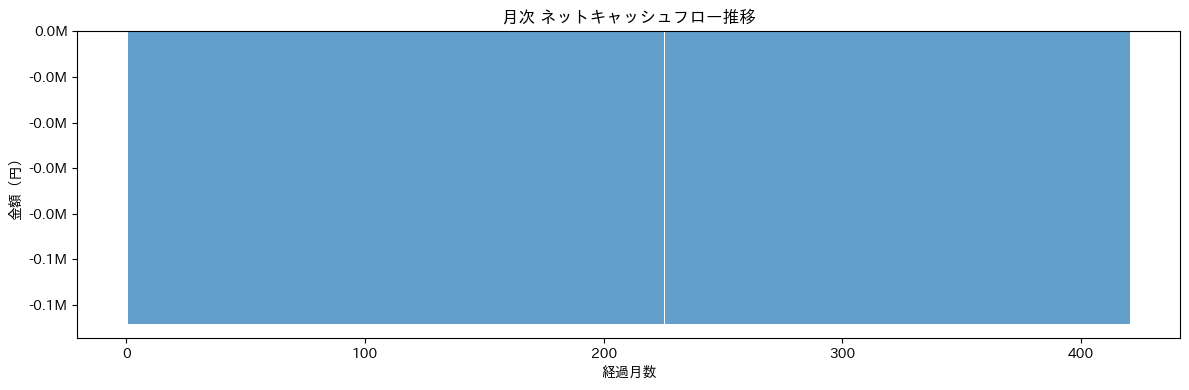

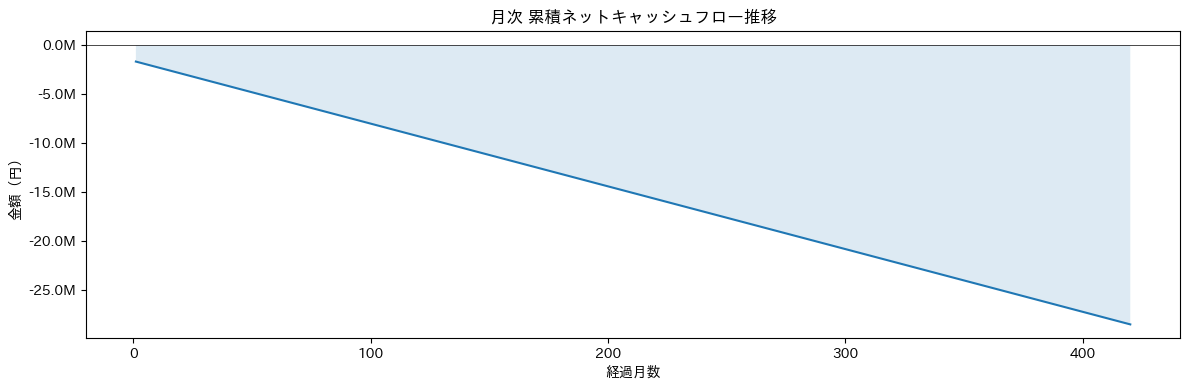

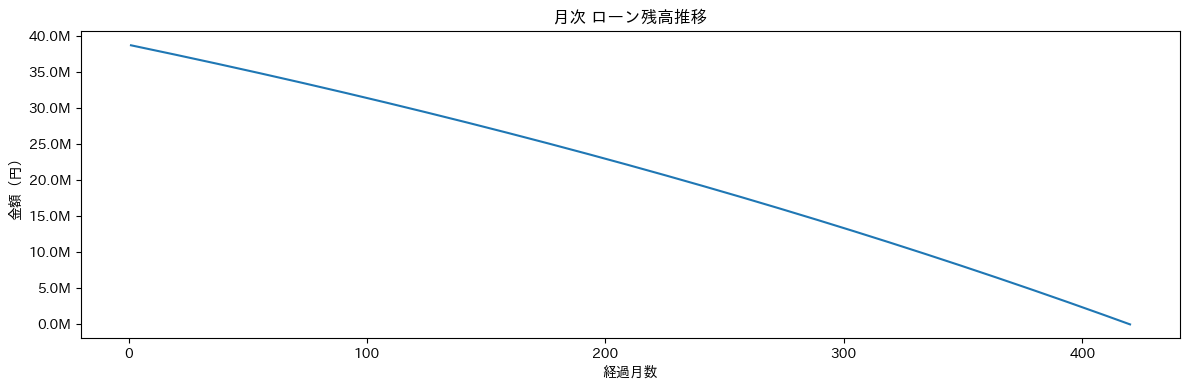

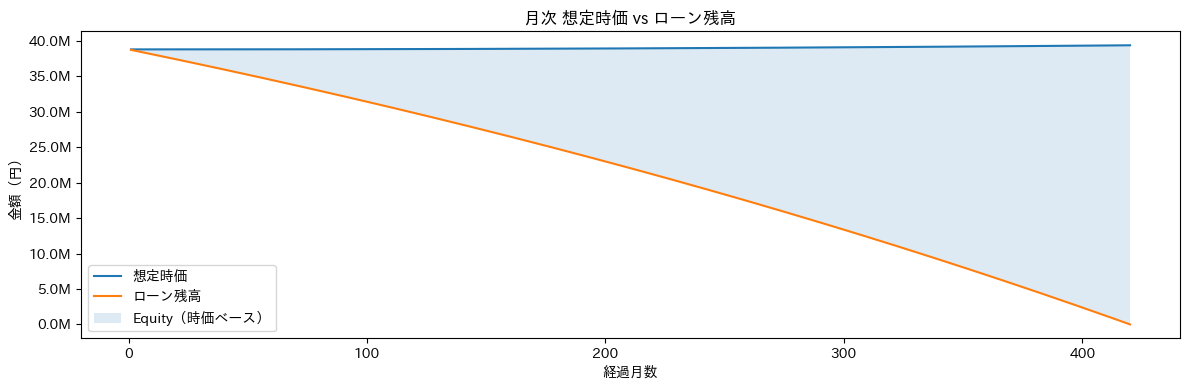

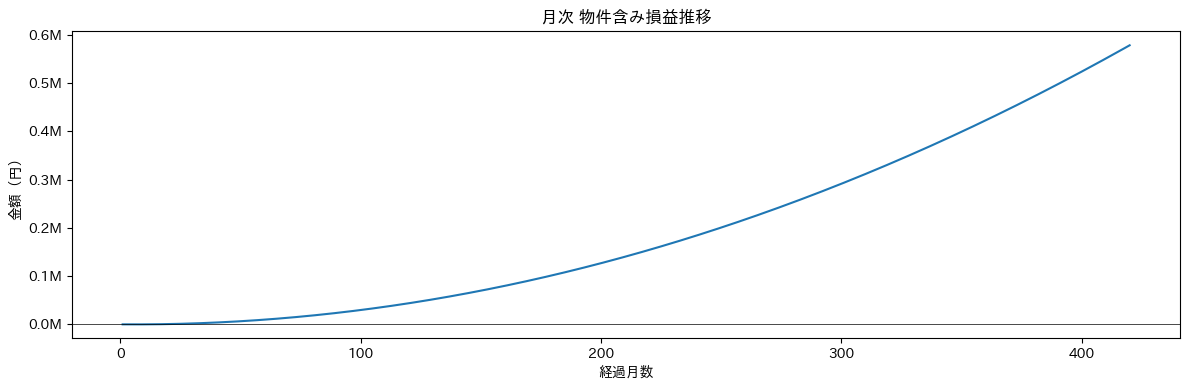

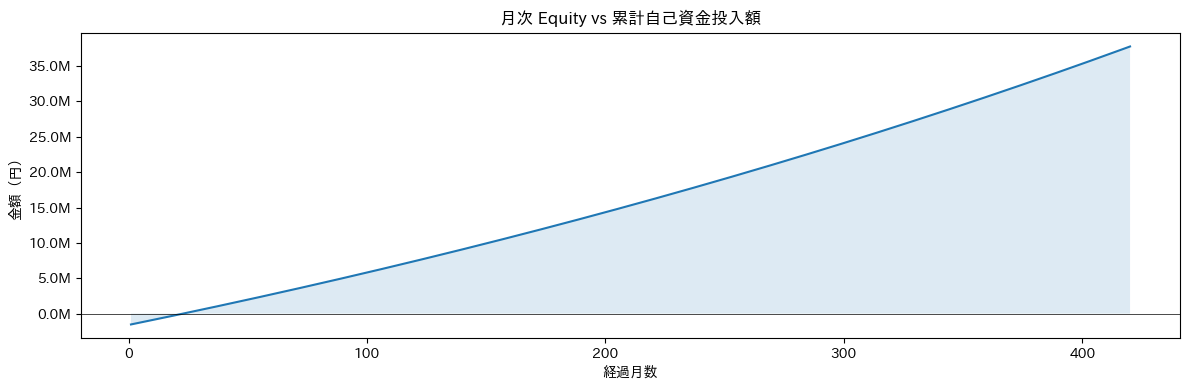

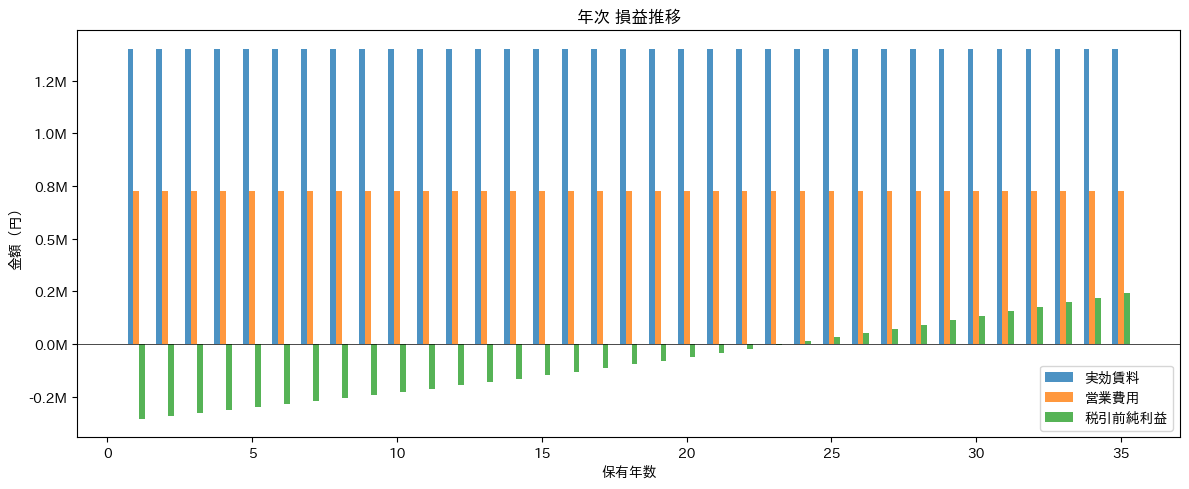

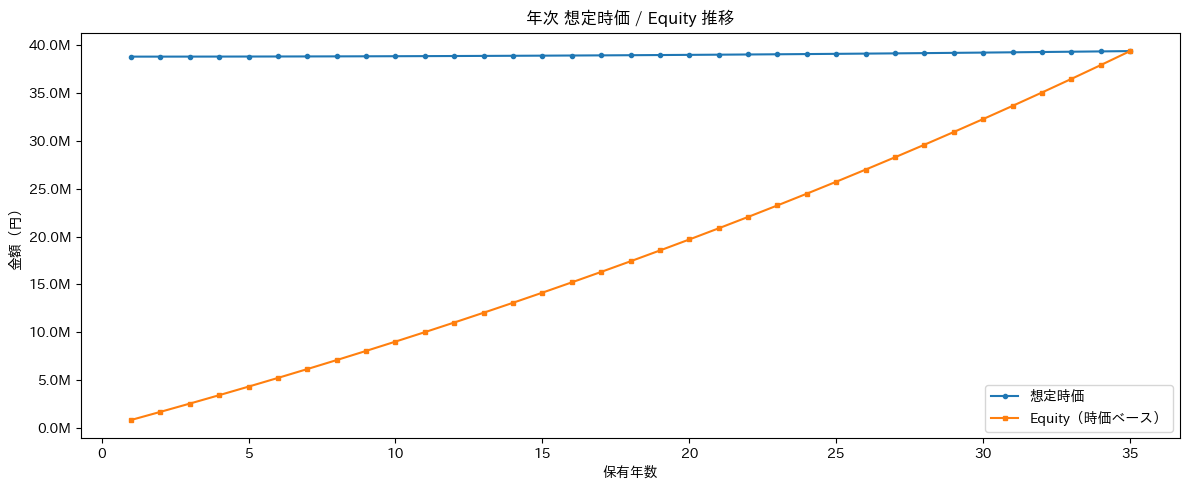

全グラフ描画完了


In [24]:
# === セル13: 可視化 ===

# 月次データ（period_month >= 1）を使用
plot_m = monthly_df[monthly_df["period_month"] >= 1].copy()
# 年次データ（year_index >= 1）を使用
plot_a = annual_df[annual_df["year_index"] >= 1].copy()

# --- グラフ1: 月次 net_cash_flow 推移 ---
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(plot_m["period_month"], plot_m["net_cash_flow"], width=1.0, alpha=0.7)
ax.axhline(y=0, color="black", linewidth=0.5)
ax.set_title("月次 ネットキャッシュフロー推移")
ax.set_xlabel("経過月数")
ax.set_ylabel("金額（円）")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))
plt.tight_layout()
plt.show()

# --- グラフ2: 月次 cumulative_net_cash_flow 推移 ---
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(plot_m["period_month"], plot_m["cumulative_net_cash_flow"], linewidth=1.5)
ax.axhline(y=0, color="black", linewidth=0.5)
ax.set_title("月次 累積ネットキャッシュフロー推移")
ax.set_xlabel("経過月数")
ax.set_ylabel("金額（円）")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))
ax.fill_between(
    plot_m["period_month"], plot_m["cumulative_net_cash_flow"], 0, alpha=0.15
)
plt.tight_layout()
plt.show()

# --- グラフ3: 月次 loan_closing_balance 推移 ---
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(plot_m["period_month"], plot_m["loan_closing_balance"], linewidth=1.5)
ax.set_title("月次 ローン残高推移")
ax.set_xlabel("経過月数")
ax.set_ylabel("金額（円）")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))
plt.tight_layout()
plt.show()

# --- グラフ4: 月次 total_market_value と loan_closing_balance ---
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(plot_m["period_month"], plot_m["total_market_value"], label="想定時価", linewidth=1.5)
ax.plot(plot_m["period_month"], plot_m["loan_closing_balance"], label="ローン残高", linewidth=1.5)
ax.fill_between(
    plot_m["period_month"],
    plot_m["loan_closing_balance"],
    plot_m["total_market_value"],
    alpha=0.15,
    label="Equity（時価ベース）",
)
ax.set_title("月次 想定時価 vs ローン残高")
ax.set_xlabel("経過月数")
ax.set_ylabel("金額（円）")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))
ax.legend()
plt.tight_layout()
plt.show()

# --- グラフ5: 月次 property_unrealized_gain_loss 推移 ---
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(plot_m["period_month"], plot_m["property_unrealized_gain_loss"], linewidth=1.5)
ax.axhline(y=0, color="black", linewidth=0.5)
ax.set_title("月次 物件含み損益推移")
ax.set_xlabel("経過月数")
ax.set_ylabel("金額（円）")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))
plt.tight_layout()
plt.show()

# --- グラフ6: 月次 equity_vs_cash_in 推移 ---
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(plot_m["period_month"], plot_m["equity_vs_cash_in"], linewidth=1.5)
ax.axhline(y=0, color="black", linewidth=0.5)
ax.set_title("月次 Equity vs 累計自己資金投入額")
ax.set_xlabel("経過月数")
ax.set_ylabel("金額（円）")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))
ax.fill_between(
    plot_m["period_month"], plot_m["equity_vs_cash_in"], 0, alpha=0.15
)
plt.tight_layout()
plt.show()

# --- グラフ7: 年次 effective_rent / opex / net_income_pl ---
fig, ax = plt.subplots(figsize=(12, 5))
x = plot_a["holding_year"]
ax.bar(x - 0.2, plot_a["effective_rent"], width=0.2, label="実効賃料", alpha=0.8)
ax.bar(x, plot_a["opex_pl"], width=0.2, label="営業費用", alpha=0.8)
ax.bar(x + 0.2, plot_a["net_income_pl"], width=0.2, label="税引前純利益", alpha=0.8)
ax.axhline(y=0, color="black", linewidth=0.5)
ax.set_title("年次 損益推移")
ax.set_xlabel("保有年数")
ax.set_ylabel("金額（円）")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))
ax.legend()
plt.tight_layout()
plt.show()

# --- グラフ8: 年次 total_market_value / equity_market_value ---
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(plot_a["holding_year"], plot_a["total_market_value"], marker="o", markersize=3, label="想定時価", linewidth=1.5)
ax.plot(plot_a["holding_year"], plot_a["equity_market_value"], marker="s", markersize=3, label="Equity（時価ベース）", linewidth=1.5)
ax.set_title("年次 想定時価 / Equity 推移")
ax.set_xlabel("保有年数")
ax.set_ylabel("金額（円）")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))
ax.legend()
plt.tight_layout()
plt.show()

print("全グラフ描画完了")

In [25]:
# === セル14: 保存処理 ===

if ENABLE_SAVE:
    ensure_dirs(OUTPUT_DIR)

    # CSV 保存
    monthly_df.to_csv(OUTPUT_DIR / "monthly_simulation.csv", index=False, encoding="utf-8-sig")
    annual_df.to_csv(OUTPUT_DIR / "annual_simulation.csv", index=False, encoding="utf-8-sig")
    loan_df.to_csv(OUTPUT_DIR / "loan_schedule.csv", index=False, encoding="utf-8-sig")
    depr_df.to_csv(OUTPUT_DIR / "depreciation_schedule.csv", index=False, encoding="utf-8-sig")
    market_df.to_csv(OUTPUT_DIR / "market_scenario_schedule.csv", index=False, encoding="utf-8-sig")
    print("CSV ファイル保存完了:")
    for f in sorted(OUTPUT_DIR.glob("*.csv")):
        print(f"  {f}")

    # Parquet 保存（pyarrow がインストールされている場合）
    try:
        monthly_df.to_parquet(OUTPUT_DIR / "monthly_simulation.parquet", index=False)
        annual_df.to_parquet(OUTPUT_DIR / "annual_simulation.parquet", index=False)
        loan_df.to_parquet(OUTPUT_DIR / "loan_schedule.parquet", index=False)
        depr_df.to_parquet(OUTPUT_DIR / "depreciation_schedule.parquet", index=False)
        market_df.to_parquet(OUTPUT_DIR / "market_scenario_schedule.parquet", index=False)
        print("\nParquet ファイル保存完了:")
        for f in sorted(OUTPUT_DIR.glob("*.parquet")):
            print(f"  {f}")
    except ImportError:
        print("\nWarning: pyarrow が未インストールのため Parquet 保存をスキップしました。")
        print("  pip install pyarrow で Parquet 保存が有効になります。")
else:
    print("ENABLE_SAVE = False のため保存をスキップしました。")
    

CSV ファイル保存完了:
  \\wsl.localhost\Ubuntu\home\kazumasa\annual_simulation.csv
  \\wsl.localhost\Ubuntu\home\kazumasa\depreciation_schedule.csv
  \\wsl.localhost\Ubuntu\home\kazumasa\healthplanet_bodyfat_pct.csv
  \\wsl.localhost\Ubuntu\home\kazumasa\healthplanet_weight.csv
  \\wsl.localhost\Ubuntu\home\kazumasa\healthplanet_weight_kg.csv
  \\wsl.localhost\Ubuntu\home\kazumasa\loan_schedule.csv
  \\wsl.localhost\Ubuntu\home\kazumasa\market_scenario_schedule.csv
  \\wsl.localhost\Ubuntu\home\kazumasa\monthly_simulation.csv
  \\wsl.localhost\Ubuntu\home\kazumasa\report_matrix_display.csv
  \\wsl.localhost\Ubuntu\home\kazumasa\report_matrix_raw.csv

Parquet ファイル保存完了:
  \\wsl.localhost\Ubuntu\home\kazumasa\annual_simulation.parquet
  \\wsl.localhost\Ubuntu\home\kazumasa\depreciation_schedule.parquet
  \\wsl.localhost\Ubuntu\home\kazumasa\loan_schedule.parquet
  \\wsl.localhost\Ubuntu\home\kazumasa\market_scenario_schedule.parquet
  \\wsl.localhost\Ubuntu\home\kazumasa\monthly_simulation.parque

## 年次投資レポートマトリクス

以下のセルで、拡張した収入・支出・税務・売却・BSスケジュールを構築し、
年次の投資レポート行列 (`report_matrix`) を生成します。

- **計算用テーブル** (`report_matrix_raw_df`): float/int の生データ
- **表示用テーブル** (`report_matrix_display_df`): 日本語行ラベル・フォーマット済み

In [21]:
# === セル15b: レポートマトリクス用スケジュール構築 ===

# --- 収入スケジュール ---
income_df = build_income_schedule(
    monthly_rent=MONTHLY_RENT_JPY,
    vacancy_rate=VACANCY_RATE,
    rent_growth_annual=RENT_GROWTH_ANNUAL,
    monthly_parking=MONTHLY_PARKING_INCOME_JPY,
    parking_growth_annual=PARKING_GROWTH_ANNUAL,
    monthly_other=MONTHLY_OTHER_INCOME_JPY,
    other_growth_annual=OTHER_INCOME_GROWTH_ANNUAL,
    start_date=SIMULATION_START_DATE,
    holding_period_years=HOLDING_PERIOD_YEARS,
    turnover_interval_years=TURNOVER_INTERVAL_YEARS,
    vacancy_months_per_turnover=VACANCY_MONTHS_PER_TURNOVER,
)
print(f"収入スケジュール shape: {income_df.shape}")

# --- 保有コストスケジュール ---
cost_df = build_operating_cost_schedule(
    purchase_price=PURCHASE_PRICE_JPY,
    fixed_asset_tax_rate_annual=FIXED_ASSET_TAX_RATE_ANNUAL,
    city_planning_tax_rate_annual=CITY_PLANNING_TAX_RATE_ANNUAL,
    fire_insurance_annual=FIRE_INSURANCE_ANNUAL_JPY,
    earthquake_insurance_annual=EARTHQUAKE_INSURANCE_ANNUAL_JPY,
    building_management_fee_monthly=BUILDING_MANAGEMENT_FEE_MONTHLY_JPY,
    pm_fee_rate=PM_FEE_RATE,
    repair_reserve_monthly=REPAIR_RESERVE_MONTHLY_JPY,
    routine_repair_monthly=ROUTINE_REPAIR_MONTHLY_JPY,
    income_df=income_df,
    loan_df=loan_df,
    depr_df=depr_df,
    large_repair_events=LARGE_REPAIR_EVENTS,
    one_time_cost_events=ONE_TIME_COST_EVENTS,
    leasing_fee_per_turnover_months=LEASING_FEE_PER_TURNOVER_MONTHS,
    leasing_fixed_cost=LEASING_FIXED_COST_JPY,
    turnover_interval_years=TURNOVER_INTERVAL_YEARS,
    monthly_rent_initial=MONTHLY_RENT_JPY,
    rent_growth_annual=RENT_GROWTH_ANNUAL,
    holding_period_years=HOLDING_PERIOD_YEARS,
)
print(f"保有コストスケジュール shape: {cost_df.shape}")

# --- 年次集計（収入） ---
income_df["year_index"] = ((income_df["period_month"] - 1) // 12) + 1
_inc_sum_cols = ["rent_income_gross", "vacancy_loss", "rent_income_effective",
                 "parking_income", "other_income", "total_income"]
annual_income_df = income_df.groupby("year_index").agg(
    {c: "sum" for c in _inc_sum_cols}
).reset_index()
annual_income_df.columns = ["year_index"] + [c + "_sum" for c in _inc_sum_cols]
# total_income は集計時にも使うので別名なしコピー
annual_income_df["total_income"] = annual_income_df["total_income_sum"]
annual_income_df["rent_income_effective_sum"] = annual_income_df["rent_income_effective_sum"]
print(f"年次収入集計 shape: {annual_income_df.shape}")

# --- 年次集計（コスト） ---
cost_df["year_index"] = ((cost_df["period_month"] - 1) // 12) + 1
_cost_sum_cols = ["fixed_asset_tax", "city_planning_tax", "fire_insurance",
                  "earthquake_insurance", "building_management_fee", "pm_fee",
                  "repair_reserve", "routine_repair", "large_repair",
                  "leasing_cost", "one_time_cost",
                  "loan_principal_payment", "loan_interest_payment",
                  "depreciation_expense", "total_opex_cf", "total_opex_pl"]
annual_cost_df = cost_df.groupby("year_index").agg(
    {c: "sum" for c in _cost_sum_cols}
).reset_index()
annual_cost_df.columns = ["year_index"] + [c + "_sum" for c in _cost_sum_cols]
annual_cost_df["total_opex_cf"] = annual_cost_df["total_opex_cf_sum"]
annual_cost_df["total_opex_pl"] = annual_cost_df["total_opex_pl_sum"]
annual_cost_df["depreciation_expense"] = annual_cost_df["depreciation_expense_sum"]
annual_cost_df["loan_interest_payment"] = annual_cost_df["loan_interest_payment_sum"]
print(f"年次コスト集計 shape: {annual_cost_df.shape}")

# --- 税務スケジュール ---
tax_df = build_tax_schedule(
    annual_income_df=annual_income_df,
    annual_cost_df=annual_cost_df,
    income_tax_rate=INCOME_TAX_RATE,
    resident_tax_rate=RESIDENT_TAX_RATE,
    allow_negative_tax_benefit=ALLOW_NEGATIVE_TAX_BENEFIT,
    holding_period_years=HOLDING_PERIOD_YEARS,
)
print(f"税務スケジュール shape: {tax_df.shape}")

# --- 売却スケジュール ---
exit_df = build_exit_schedule(
    annual_income_df=annual_income_df,
    annual_cost_df=annual_cost_df,
    tax_df=tax_df,
    loan_df=loan_df,
    depr_df=depr_df,
    market_df=market_df,
    purchase_price=PURCHASE_PRICE_JPY,
    land_ratio=LAND_RATIO,
    building_ratio=BUILDING_RATIO,
    down_payment=DOWN_PAYMENT_JPY,
    acquisition_misc_cost=ACQUISITION_MISC_COST_JPY,
    sale_year=SALE_YEAR,
    sale_price_method=SALE_PRICE_METHOD,
    direct_sale_price=DIRECT_SALE_PRICE_JPY,
    exit_cap_rate=EXIT_CAP_RATE,
    selling_broker_fee_rate=SELLING_BROKER_FEE_RATE,
    selling_other_cost=SELLING_OTHER_COST_JPY,
    loan_prepayment_fee_rate=LOAN_PREPAYMENT_FEE_RATE,
    capital_gains_tax_rate=CAPITAL_GAINS_TAX_RATE,
    holding_period_years=HOLDING_PERIOD_YEARS,
)
print(f"売却スケジュール shape: {exit_df.shape}")

# --- バランスシートスケジュール ---
bs_df = build_balance_sheet_schedule(
    annual_income_df=annual_income_df,
    annual_cost_df=annual_cost_df,
    tax_df=tax_df,
    loan_df=loan_df,
    depr_df=depr_df,
    market_df=market_df,
    purchase_price=PURCHASE_PRICE_JPY,
    land_ratio=LAND_RATIO,
    building_ratio=BUILDING_RATIO,
    down_payment=DOWN_PAYMENT_JPY,
    acquisition_misc_cost=ACQUISITION_MISC_COST_JPY,
    holding_period_years=HOLDING_PERIOD_YEARS,
)
print(f"バランスシートスケジュール shape: {bs_df.shape}")

# --- レポートマトリクス ---
report_matrix_raw_df, report_matrix_display_df = build_report_matrix(
    annual_income_df=annual_income_df,
    annual_cost_df=annual_cost_df,
    tax_df=tax_df,
    exit_df=exit_df,
    bs_df=bs_df,
    market_df=market_df,
    purchase_price=PURCHASE_PRICE_JPY,
    land_ratio=LAND_RATIO,
    building_ratio=BUILDING_RATIO,
    built_year_month=BUILT_YEAR_MONTH,
    simulation_start_date=SIMULATION_START_DATE,
    owner_age_at_start=OWNER_AGE_AT_START,
    holding_period_years=HOLDING_PERIOD_YEARS,
    large_repair_events=LARGE_REPAIR_EVENTS,
)
print(f"レポートマトリクス shape: raw={report_matrix_raw_df.shape}, display={report_matrix_display_df.shape}")
print("\n全スケジュール構築完了")

収入スケジュール shape: (420, 8)
保有コストスケジュール shape: (420, 17)
年次収入集計 shape: (35, 8)
年次コスト集計 shape: (35, 21)
税務スケジュール shape: (35, 6)
売却スケジュール shape: (35, 12)
バランスシートスケジュール shape: (35, 12)
レポートマトリクス shape: raw=(35, 58), display=(65, 36)

全スケジュール構築完了


In [68]:
# === セル15c: レポートマトリクス表示 ===

print("=== 年次投資レポートマトリクス ===")
# 横スクロール用にスタイル設定
with pd.option_context("display.max_columns", None, "display.width", None, "display.max_colwidth", 20):
    display(report_matrix_display_df)

=== 年次投資レポートマトリクス ===


,項目,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35
0,保有年数,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35
1,築年,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35
2,年齢,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
3,【収入】,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
4,賃料合計,"1,401,060","1,401,060","1,401,060","1,401,060","1,401,060","1,401,060","1,401,060","1,401,060","1,401,060","1,401,060","1,401,060","1,401,060","1,401,060","1,401,060","1,401,060","1,401,060","1,401,060","1,401,060","1,401,060","1,401,060","1,401,060","1,401,060","1,401,060","1,401,060","1,401,060","1,401,060","1,401,060","1,401,060","1,401,060","1,401,060","1,401,060","1,401,060","1,401,060","1,401,060","1,401,060"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60,想定PL,0,970,"2,910","5,820","9,700","14,550","20,371","27,162","34,923","43,655","53,358","64,032","75,677","88,294","101,883","116,444","131,978","148,484","165,964","184,418","203,845","224,247","245,625","267,978","291,307","315,613","340,896","367,157","394,396","422,615","451,813","481,993","513,153","545,295","578,421"
61,表面利回り,3.80%,3.80%,3.80%,3.80%,3.80%,3.80%,3.80%,3.80%,3.80%,3.80%,3.80%,3.79%,3.79%,3.79%,3.79%,3.79%,3.79%,3.79%,3.78%,3.78%,3.78%,3.78%,3.78%,3.77%,3.77%,3.77%,3.77%,3.77%,3.76%,3.76%,3.76%,3.75%,3.75%,3.75%,3.75%
62,価格変化,0,970,"2,910","5,820","9,700","14,550","20,371","27,162","34,923","43,655","53,358","64,032","75,677","88,294","101,883","116,444","131,978","148,484","165,964","184,418","203,845","224,247","245,625","267,978","291,307","315,613","340,896","367,157","394,396","422,615","451,813","481,993","513,153","545,295","578,421"
63,価格変化率,0.00%,0.00%,0.01%,0.02%,0.03%,0.04%,0.05%,0.07%,0.09%,0.11%,0.14%,0.17%,0.20%,0.23%,0.26%,0.30%,0.34%,0.38%,0.43%,0.48%,0.53%,0.58%,0.63%,0.69%,0.75%,0.81%,0.88%,0.95%,1.02%,1.09%,1.16%,1.24%,1.32%,1.41%,1.49%


In [27]:
# === セル15d: KPI 年次比較表 ===

_kpi_years = [1, 5, 10, 15, 20, 30]
_kpi_years_available = [y for y in _kpi_years if y <= HOLDING_PERIOD_YEARS]

kpi_rows = []
for y in _kpi_years_available:
    r = report_matrix_raw_df[report_matrix_raw_df["holding_year"] == y].iloc[0]
    kpi_rows.append({
        "保有年数": y,
        "年間賃料収入": f"{r['income_rent_total']:,.0f}",
        "年間CF（税引後）": f"{r['cf_after_tax']:,.0f}",
        "累積CF（税引後）": f"{r['cf_after_tax_cumulative']:,.0f}",
        "年間PL（税引後）": f"{r['pl_after_tax']:,.0f}",
        "BS純資産": f"{r['bs_net_assets']:,.0f}",
        "ローン残高": f"{r['bs_loan']:,.0f}",
        "想定時価": f"{r['eval_total_mv']:,.0f}",
        "表面利回り": f"{r['eval_gross_yield']:.2%}",
        "売却時リターン": f"{r['exit_total_return']:,.0f}",
    })

kpi_df = pd.DataFrame(kpi_rows).set_index("保有年数")
print("=== KPI 年次比較表 ===")
display(kpi_df.T)

=== KPI 年次比較表 ===


保有年数,1,5,10,15,20,30
年間賃料収入,"1,401,060","1,401,060","1,401,060","1,401,060","1,401,060","1,401,060"
年間CF（税引後）,"-573,723","-603,873","-644,357","-688,188","-735,645","-842,653"
累積CF（税引後）,"-573,723","-2,943,390","-6,082,919","-9,434,806","-13,016,608","-20,947,581"
年間PL（税引後）,"-160,102","-135,434","-102,311","-66,448","-27,621","59,932"
BS純資産,"413,621","2,204,061","4,764,737","7,711,517","11,076,328","19,201,162"
ローン残高,"37,964,640","34,487,244","29,817,872","24,762,396","19,288,890","6,946,664"
想定時価,"38,800,000","38,809,700","38,843,655","38,901,883","38,984,418","39,222,615"
表面利回り,3.80%,3.80%,3.80%,3.79%,3.78%,3.76%
売却時リターン,"-2,502,363","-1,579,051","-451,345","868,871","2,395,987","6,134,590"


In [74]:
# === セル15e: レポートマトリクス保存 ===

if ENABLE_SAVE:
    ensure_dirs(OUTPUT_DIR)
    report_matrix_raw_df.to_csv(OUTPUT_DIR / "report_matrix_raw.csv", index=False, encoding="utf-8-sig")
    report_matrix_display_df.to_csv(OUTPUT_DIR / "report_matrix_display.csv", encoding="utf-8-sig")
    print("レポートマトリクス保存完了:")
    print(f"  {OUTPUT_DIR / 'report_matrix_raw.csv'}")
    print(f"  {OUTPUT_DIR / 'report_matrix_display.csv'}")
else:
    print("ENABLE_SAVE = False のため保存をスキップしました。")

レポートマトリクス保存完了:
  \\wsl.localhost\Ubuntu\home\kazumasa\report_matrix_raw.csv
  \\wsl.localhost\Ubuntu\home\kazumasa\report_matrix_display.csv


## 次ステップ（将来拡張候補）

本 Notebook はベース版です。以下の機能を段階的に追加していく予定です。

### 売却関連
- 売却イベントの追加（任意のタイミングでの売却シミュレーション）
- 売却コスト（仲介手数料・印紙代等）
- 譲渡税（短期・長期の区分、取得費・譲渡費用の計算）
- 売却後の最終リターン計算（IRR・倍率）

### 税務関連
- 所得税・住民税の簡易計算（税引後キャッシュフロー）
- 損益通算の考慮（給与所得との通算）
- 青色申告特別控除
- 法人スキームとの比較

### シナリオ・リスク分析
- 金利上昇シナリオ（変動金利対応）
- 空室率の時変化（築年数に応じた上昇など）
- 家賃改定イベント（レントロールベースの入退去モデル）
- 修繕費イベント（大規模修繕の一時費用）
- 複数シナリオ比較（楽観・基本・悲観）
- 感度分析（モンテカルロ・トルネードチャート）

### 拡張機能
- 繰上返済シミュレーション
- 複数物件ポートフォリオ対応
- 固定資産税の精緻化（評価額ベース・経年減価）
- 入力パラメータの dataclass 化
- Web UI / Streamlit 対応
- 外部データ連携（REINS / 不動産ポータルサイト）

In [28]:
# === セル16: Excel エクスポート with フォーマッティング ===

if ENABLE_SAVE:
    ensure_dirs(OUTPUT_DIR)
    
    excel_file = OUTPUT_DIR / "年次投資シミュレーション.xlsx"
    
    try:
        from openpyxl.styles import Font, PatternFill, Alignment, Border, Side, numbers
        
        # フォーマッティング設定
        header_fill = PatternFill(start_color="4472C4", end_color="4472C4", fill_type="solid")
        header_font = Font(color="FFFFFF", bold=True)
        center_align = Alignment(horizontal="center", vertical="center", wrap_text=True)
        right_align = Alignment(horizontal="right", vertical="center")
        currency_format = '#,##0'
        percentage_format = '0.00%'
        decimal_format = '#,##0.00'
        thin_border = Border(
            left=Side(style='thin'),
            right=Side(style='thin'),
            top=Side(style='thin'),
            bottom=Side(style='thin')
        )
        
        def format_sheet(ws, df, currency_cols=None, percentage_cols=None, decimal_cols=None):
            """シートをフォーマッティング"""
            if currency_cols is None:
                currency_cols = []
            if percentage_cols is None:
                percentage_cols = []
            if decimal_cols is None:
                decimal_cols = []
            
            # ヘッダーのフォーマッティング
            for cell in ws[1]:
                if cell.value:
                    cell.fill = header_fill
                    cell.font = header_font
                    cell.alignment = center_align
                    cell.border = thin_border
            
            # データのフォーマッティング
            for row_idx, row in enumerate(ws.iter_rows(min_row=2, max_row=ws.max_row), start=2):
                for col_idx, cell in enumerate(row, start=1):
                    if cell.value is not None:
                        cell.border = thin_border
                        
                        # 列インデックスでフォーマット判定
                        col_letter = cell.column_letter
                        col_num = col_idx
                        
                        if col_num in currency_cols or col_letter in currency_cols:
                            # 通貨形式
                            if isinstance(cell.value, (int, float)):
                                cell.number_format = currency_format
                                cell.alignment = right_align
                        elif col_num in percentage_cols or col_letter in percentage_cols:
                            # パーセンテージ
                            if isinstance(cell.value, (int, float)):
                                cell.number_format = percentage_format
                                cell.alignment = right_align
                        elif col_num in decimal_cols or col_letter in decimal_cols:
                            # 小数形式
                            if isinstance(cell.value, (int, float)):
                                cell.number_format = decimal_format
                                cell.alignment = right_align
                        elif isinstance(cell.value, (int, float)) and col_num > 1:
                            # その他の数値は右寄せ
                            cell.number_format = currency_format
                            cell.alignment = right_align
            
            # 列幅の自動調整
            for column in ws.columns:
                max_width = 0
                col_letter = column[0].column_letter
                for cell in column:
                    try:
                        if cell.value:
                            cell_width = len(str(cell.value)) + 2
                            max_width = max(max_width, cell_width)
                    except:
                        pass
                adjusted_width = min(max_width + 1, 50)
                ws.column_dimensions[col_letter].width = adjusted_width
        
        with pd.ExcelWriter(excel_file, engine="openpyxl") as writer:
            # シート1: レポートマトリクス（先頭に配置、横軸=年）
            report_display = report_matrix_display_df.copy()
            report_display.to_excel(writer, sheet_name="レポートマトリクス", index=False)
            ws = writer.sheets["レポートマトリクス"]
            
            # フォーマッティング色の定義
            red_font = Font(color="C00000", bold=False)  # 赤色フォント
            red_bold_font = Font(color="C00000", bold=True)  # 赤色太字
            highlight_fill = PatternFill(start_color="FFFF99", end_color="FFFF99", fill_type="solid")  # 黄ハイライト
            red_highlight_fill = PatternFill(start_color="FFE6E6", end_color="FFE6E6", fill_type="solid")  # 淡い赤背景
            gray_fill = PatternFill(start_color="E7E6E6", end_color="E7E6E6", fill_type="solid")  # グレー背景
            gray_font = Font(bold=True, color="000000")  # グレーセクション用
            
            # 支出セクション行と重要行を定義
            expense_keywords = [
                "固定資産税", "都市計画税", "地震火災保険料", "管理費", "PM手数料",
                "ローン元金返済", "ローン利息返済", "修繕積立金", "通常修繕", "大規模修繕",
                "入居募集", "一時費用", "減価償却費", "PL費用合計", "CF費用合計",
                "支出", "仲介手数料", "繰上返済手数料", "諸経費"
            ]
            highlight_keywords = [
                "税引後", "利益剰余金", "純資産", "トータルリターン", 
                "税引後累積", "税引前", "税"
            ]
            section_keywords = ["【", "】"]
            
            for row_idx, row in enumerate(ws.iter_rows(min_row=1, max_row=ws.max_row)):
                row_label = str(row[0].value) if row[0].value else ""
                
                # 行全体のフォーマッティング判定
                is_expense = any(kw in row_label for kw in expense_keywords)
                is_highlight = any(kw in row_label for kw in highlight_keywords)
                is_section = any(kw in row_label for kw in section_keywords)
                
                for col_idx, cell in enumerate(row, start=1):
                    cell.border = thin_border
                    
                    if cell.row == 1:
                        # ヘッダー行
                        cell.fill = header_fill
                        cell.font = header_font
                        cell.alignment = center_align
                    else:
                        # データ行
                        cell.alignment = right_align
                        
                        if col_idx == 1:
                            # 1列目：項目ラベル行
                            if is_section:
                                cell.font = gray_font
                                cell.fill = gray_fill
                            elif is_highlight:
                                cell.font = Font(bold=True)
                                cell.fill = highlight_fill
                        else:
                            # 2列目以降：数値セル
                            if isinstance(cell.value, (int, float)):
                                # 数値のフォーマッティング
                                if abs(cell.value) < 1:
                                    # パーセンテージ
                                    cell.number_format = percentage_format
                                else:
                                    # 通貨
                                    cell.number_format = currency_format
                                
                                # 支出行：赤文字 + マイナス値（既に負数）
                                if is_expense:
                                    if is_highlight:
                                        cell.fill = red_highlight_fill
                                    cell.font = red_font
                                # 重要行（非支出）：ハイライト背景
                                elif is_highlight:
                                    cell.fill = highlight_fill
                                    cell.font = Font(bold=True)
            
            # 列幅の自動調整
            for column in ws.columns:
                max_width = 0
                col_letter = column[0].column_letter
                for cell in column:
                    try:
                        if cell.value:
                            cell_width = len(str(cell.value)) + 2
                            max_width = max(max_width, cell_width)
                    except:
                        pass
                adjusted_width = min(max_width + 1, 50)
                ws.column_dimensions[col_letter].width = adjusted_width
            
            # シート2: 年次集計
            annual_df_display = annual_df.copy()
            annual_df_display.to_excel(writer, sheet_name="年次集計", index=False)
            ws = writer.sheets["年次集計"]
            # 3列目以降を通貨フォーマット（年、築年を除外）
            currency_cols = list(range(3, annual_df_display.shape[1] + 1))
            format_sheet(ws, annual_df_display, currency_cols=currency_cols)
            
            # シート3: 収入集計
            annual_income_display = annual_income_df.copy()
            annual_income_display.to_excel(writer, sheet_name="年次収入", index=False)
            ws = writer.sheets["年次収入"]
            currency_cols = list(range(2, annual_income_display.shape[1] + 1))
            format_sheet(ws, annual_income_display, currency_cols=currency_cols)
            
            # シート4: コスト集計
            annual_cost_display = annual_cost_df.copy()
            annual_cost_display.to_excel(writer, sheet_name="年次コスト", index=False)
            ws = writer.sheets["年次コスト"]
            currency_cols = list(range(2, annual_cost_display.shape[1] + 1))
            format_sheet(ws, annual_cost_display, currency_cols=currency_cols)
            
            # シート5: 税務
            tax_display = tax_df.copy()
            tax_display.to_excel(writer, sheet_name="税務", index=False)
            ws = writer.sheets["税務"]
            currency_cols = list(range(2, tax_display.shape[1] + 1))
            format_sheet(ws, tax_display, currency_cols=currency_cols)
            
            # シート6: バランスシート
            bs_display = bs_df.copy()
            bs_display.to_excel(writer, sheet_name="BS", index=False)
            ws = writer.sheets["BS"]
            currency_cols = list(range(2, bs_display.shape[1] + 1))
            format_sheet(ws, bs_display, currency_cols=currency_cols)
            
            # シート7: 売却PL
            exit_display = exit_df.copy()
            exit_display.to_excel(writer, sheet_name="売却PL", index=False)
            ws = writer.sheets["売却PL"]
            currency_cols = list(range(2, exit_display.shape[1] + 1))
            format_sheet(ws, exit_display, currency_cols=currency_cols)
            
            # シート8: KPI比較表
            kpi_display = kpi_df.copy()
            kpi_display.to_excel(writer, sheet_name="KPI比較")
            ws = writer.sheets["KPI比較"]
            # KPIは値によって異なるため、全て右寄せのみ
            for row in ws.iter_rows(min_row=2, max_row=ws.max_row):
                for cell in row:
                    if cell.column > 1 and isinstance(cell.value, (int, float)):
                        cell.alignment = right_align
                        cell.border = thin_border
                        # 数値の大きさに応じてフォーマット判定
                        if abs(cell.value) > 100:
                            cell.number_format = currency_format
                        elif cell.value < 1:
                            cell.number_format = percentage_format
                        else:
                            cell.number_format = decimal_format
            
            # シート9: サマリー指標
            summary_display = summary_df.copy()
            summary_display.to_excel(writer, sheet_name="サマリー指標", index=False)
            ws = writer.sheets["サマリー指標"]
            currency_cols = list(range(2, summary_display.shape[1] + 1))
            format_sheet(ws, summary_display, currency_cols=currency_cols)
        
        print(f"✓ Excel保存完了: {excel_file}")
        print(f"  シート数: 9")
        print(f"  レポートマトリクス シートのフォーマッティング:")
        print(f"    - 支出行: マイナス値 + 赤文字 + 淡い赤背景（全行）")
        print(f"    - 重要行（税引後/利益剰余金/純資産/トータルリターン）: 黄色背景（全行）")
        print(f"    - セクションヘッダー（【収入】【支出】等）: グレー背景（全行）")
        print(f"    - その他シートのフォーマッティング:")
        print(f"      - ヘッダー: 青背景 + 白文字")
        print(f"      - 数値: カンマ区切り（¥形式）")
        print(f"      - 列幅: 自動調整")
        print(f"      - セル枠線: 全セル")
    
    except ImportError as e:
        print("⚠ openpyxl がインストールされていません。以下のコマンドで install してください:")
        print("  pip install openpyxl")
    except Exception as e:
        print(f"✗ Excel保存エラー: {type(e).__name__}: {e}")
        import traceback
        traceback.print_exc()
else:
    print("ENABLE_SAVE = False のため Excel 保存をスキップしました。")

✓ Excel保存完了: \\wsl.localhost\Ubuntu\home\kazumasa\年次投資シミュレーション.xlsx
  シート数: 9
  レポートマトリクス シートのフォーマッティング:
    - 支出行: マイナス値 + 赤文字 + 淡い赤背景（全行）
    - 重要行（税引後/利益剰余金/純資産/トータルリターン）: 黄色背景（全行）
    - セクションヘッダー（【収入】【支出】等）: グレー背景（全行）
    - その他シートのフォーマッティング:
      - ヘッダー: 青背景 + 白文字
      - 数値: カンマ区切り（¥形式）
      - 列幅: 自動調整
      - セル枠線: 全セル


WindowsPath('//wsl.localhost/Ubuntu/home/kazumasa')